In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sergionefedov_everest_and_the_death_zone_will_they_summit_path = kagglehub.dataset_download('sergionefedov/everest-and-the-death-zone-will-they-summit')

print('Data source import complete.')


100%|██████████| 1.12M/1.12M [00:00<00:00, 45.6MB/s]

Extracting files...
Data source import complete.


<img src="https://devra.ai/analyst/notebook/6326/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">
    <div style="font-size:150%; color:#FEE100"><b>Exploring Everest Summit Data</b></div>
    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div>
</div>

It is fascinating to consider that each row of data represents not only a climber's attempt on Everest but also the interplay of numerous factors like weather, experience, and team dynamics in the extreme conditions near the summit. If you find these insights useful, feel free to upvote this notebook.

## Table of Contents

1. [Data Loading and Overview](#Data-Loading-and-Overview)
2. [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
3. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4. [Predictor Modeling](#Predictor-Modeling)
5. [Conclusions and Future Work](#Conclusions-and-Future-Work)

In [2]:
# Imports and configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

from pathlib import Path

# Helper function to resolve file paths
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Additional imports for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")

## Data Loading and Overview

In this section, we load the Everest summit datasets. One dataset provides a description of the fields while the other contains the main data on climbers and their summit attempts. This dual perspective allows us to contextualize the variables during the analysis.

In [3]:
from pathlib import Path

# Add the downloaded dataset path to DATA_ROOTS if it's not already there
# This ensures resolve_data_file can find the files.
# The 'sergionefedov_everest_and_the_death_zone_will_they_summit_path' variable
# is available in the global scope from the initial data import cell.
downloaded_data_path = Path(sergionefedov_everest_and_the_death_zone_will_they_summit_path)
if downloaded_data_path not in DATA_ROOTS:
    DATA_ROOTS.append(downloaded_data_path)

# Load the data dictionary
try:
    data_dict_file = resolve_data_file(file_name='data_dictionary.csv')
    data_dict = pd.read_csv(data_dict_file, encoding='utf-8', delimiter=',')
    print('Data Dictionary loaded successfully.')
except Exception as e:
    print('Error loading data dictionary:', e)

# Load the main Everest summit data
try:
    summit_file = resolve_data_file(file_name='everest_summit_master.csv')
    df = pd.read_csv(summit_file, encoding='ascii', delimiter=',')
    print('Everest Summit Data loaded successfully.')
except Exception as e:
    print('Error loading Everest summit data:', e)

# Quick overview of the main data
print('Data Shape:', df.shape)
print('Data Columns:', list(df.columns))

Data Dictionary loaded successfully.
Everest Summit Data loaded successfully.
Data Shape: (45000, 25)
Data Columns: ['climber_id', 'year', 'season', 'route', 'age', 'sex', 'is_hired_staff', 'years_climbing', 'prior_8000m_peaks', 'prior_everest_attempts', 'highest_prev_altitude_m', 'operator_tier', 'team_size', 'sherpa_ratio', 'uses_oxygen', 'o2_start_altitude_m', 'days_acclimatizing', 'camps_established', 'summit_window_days', 'weather_score', 'jetstream_risk', 'queue_minutes_above_8000', 'turnaround_reason', 'serious_incident', 'summited']


## Data Cleaning and Preprocessing

Here we take a closer look at the data. Tasks include checking data types, handling missing values, and converting dates if any (none are present explicitly, but should one appear we would infer the type). The goal here is to prepare a well-structured dataset for analysis.

In [4]:
# Display info about the dataframe
print(df.info())

# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

# For this dataset, assuming minimal missing values, we'll drop rows with missing data.
df_clean = df.dropna()
print('Data shape after cleaning:', df_clean.shape)

# Convert any date columns if present
# In this dataset, there is no explicit date column. If there were, we would use pd.to_datetime.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   climber_id                45000 non-null  object 
 1   year                      45000 non-null  int64  
 2   season                    45000 non-null  object 
 3   route                     45000 non-null  object 
 4   age                       45000 non-null  int64  
 5   sex                       45000 non-null  object 
 6   is_hired_staff            45000 non-null  int64  
 7   years_climbing            45000 non-null  int64  
 8   prior_8000m_peaks         45000 non-null  int64  
 9   prior_everest_attempts    45000 non-null  int64  
 10  highest_prev_altitude_m   45000 non-null  int64  
 11  operator_tier             45000 non-null  object 
 12  team_size                 45000 non-null  int64  
 13  sherpa_ratio              45000 non-null  float64
 14  uses_o

## Exploratory Data Analysis

We now explore the data using a variety of visualizations. Notice how each plot may reveal different insights about climbing patterns, participant demographics, and expedition variables. In particular, a correlation heatmap is applied if at least four numeric columns exist.

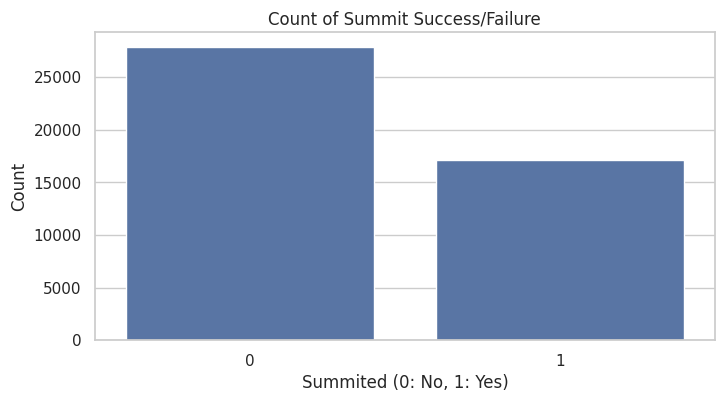

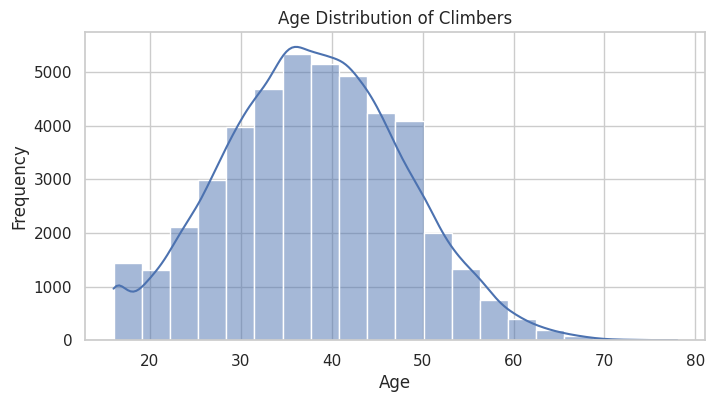

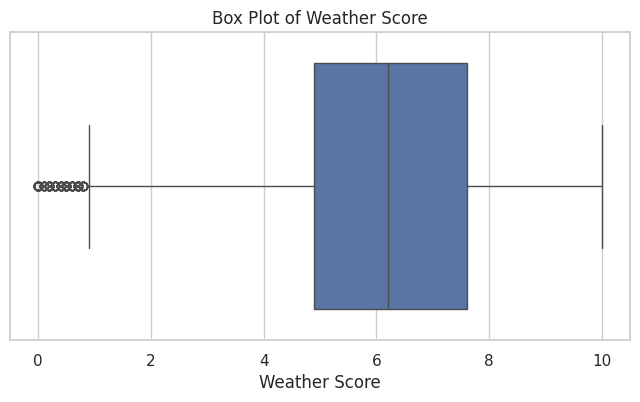

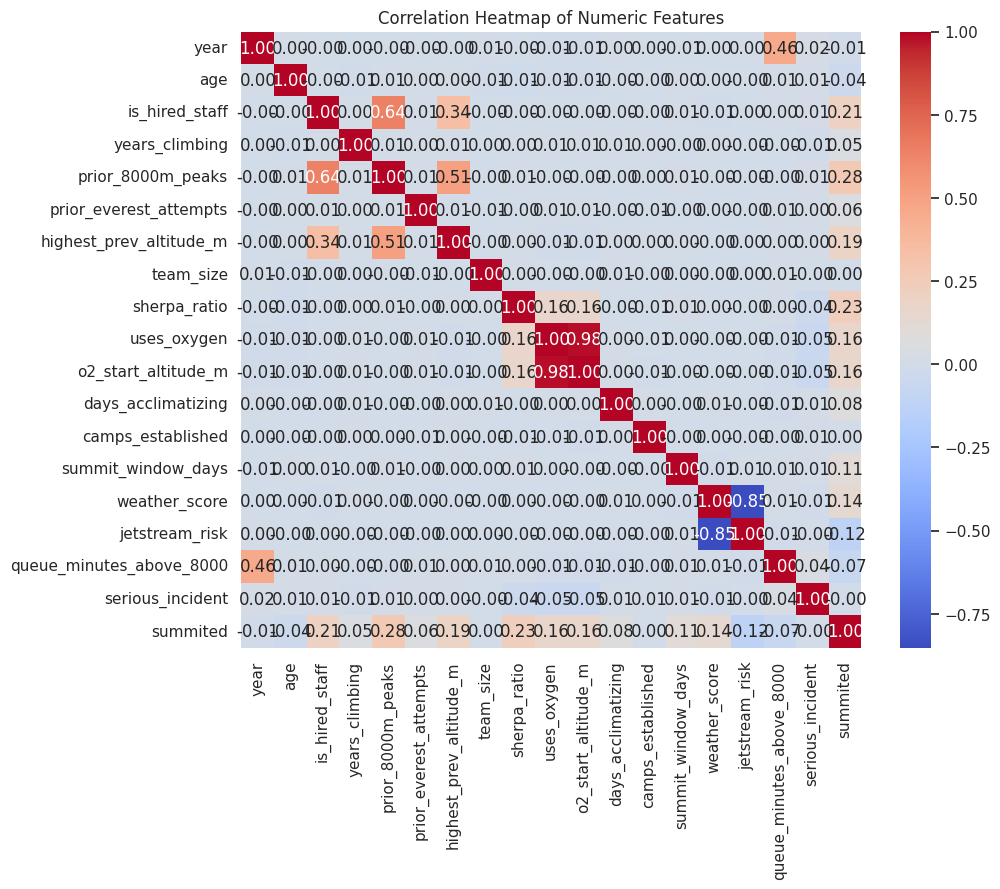

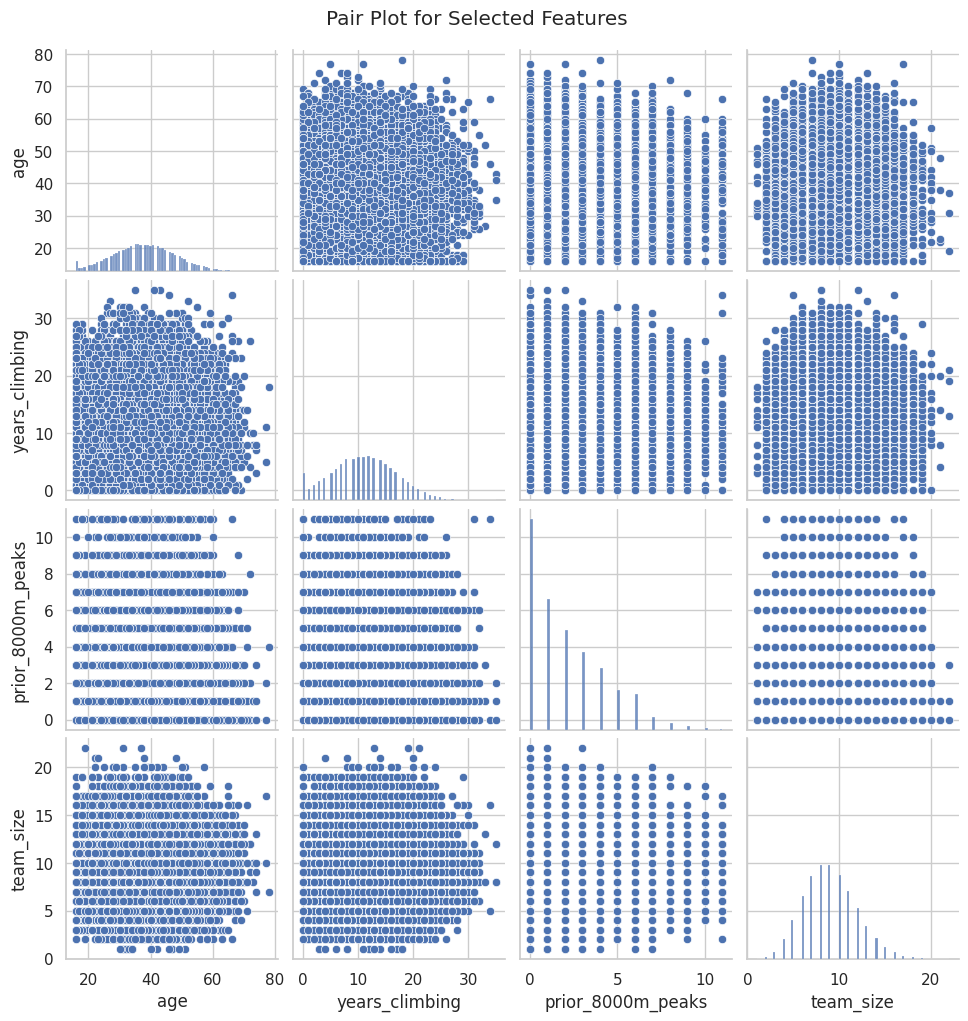

In [5]:
# Count plot for summited column
plt.figure(figsize=(8, 4))
sns.countplot(x='summited', data=df_clean)
plt.title('Count of Summit Success/Failure')
plt.xlabel('Summited (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# Histogram for climber age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['age'], kde=True, bins=20)
plt.title('Age Distribution of Climbers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Box plot for weather_score
plt.figure(figsize=(8, 4))
sns.boxplot(x='weather_score', data=df_clean)
plt.title('Box Plot of Weather Score')
plt.xlabel('Weather Score')
plt.show()

# If there are four or more numeric columns, produce a correlation heatmap
numeric_df = df_clean.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Pair plot for select numeric features
cols_for_pairplot = ['age', 'years_climbing', 'prior_8000m_peaks', 'team_size']
sns.pairplot(df_clean[cols_for_pairplot])
plt.suptitle('Pair Plot for Selected Features', y=1.02)
plt.show()

## Predictor Modeling

Next we build a predictor to determine which factors might be important for a successful summit. Considering the binary target variable "summited", we use logistic regression as a starting point. The input features include a mix of experience and environmental variables. Although simple, this predictor provides a baseline from which more sophisticated modeling might evolve.


--- Re-running Logistic Regression with Data Leakage Addressed ---

Prediction Accuracy (Logistic Regression, No Leakage): 0.709


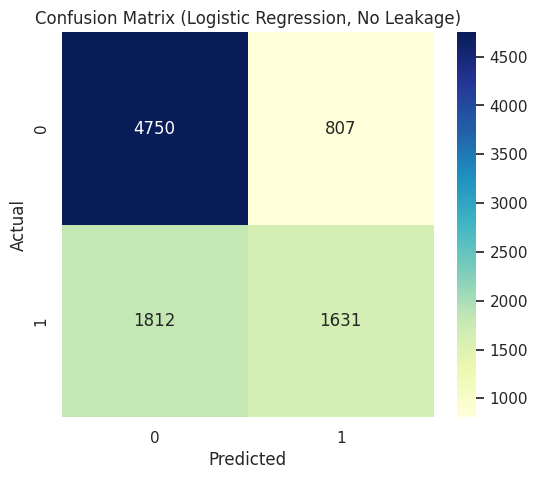

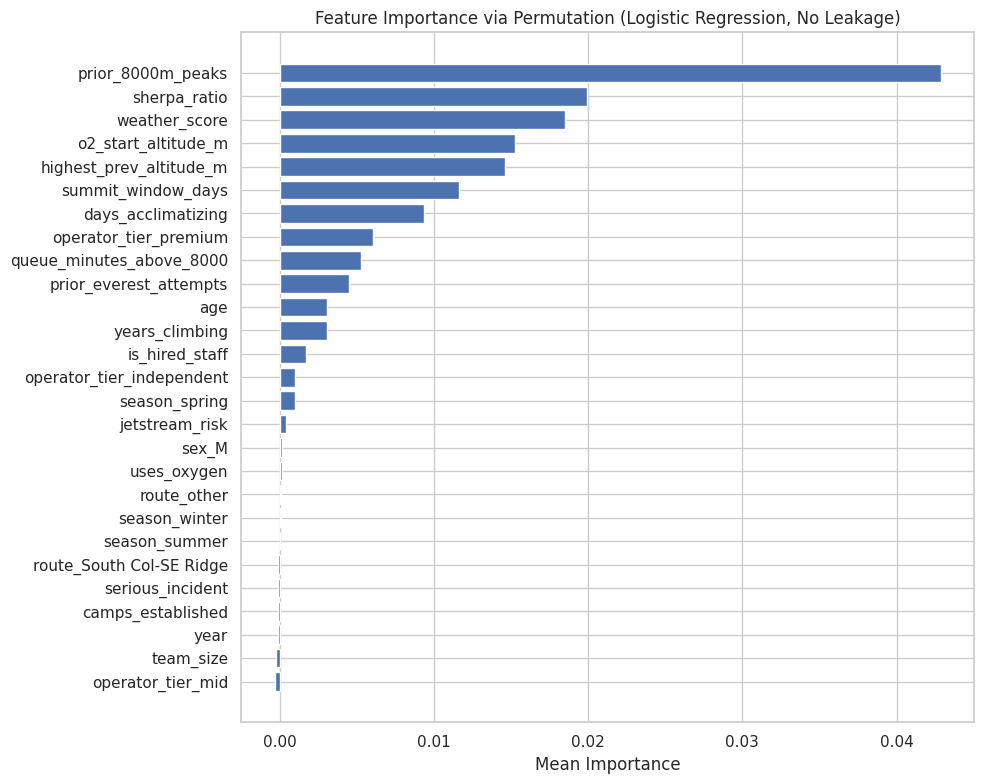

In [13]:
# Feature selection: choose a subset of numeric features that we suspect are predictive
# The 'features' list is now globally updated by the one-hot encoding step.

# X and y are already updated globally by the one-hot encoding step.
# X_train, X_test, y_train, y_test are also updated globally by the one-hot encoding step.

print("\n--- Re-running Logistic Regression with Data Leakage Addressed ---\n")

# Fit a logistic regression model with the encoded data
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the test set and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy (Logistic Regression, No Leakage):', accuracy)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression, No Leakage)')
plt.show()

# Permutation importance to assess feature contributions
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
# Ensure feature names are aligned with the new 'features' list
current_features = X_train.columns.tolist() # Get actual column names from X_train
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 8)) # Increased figure size for more features
plt.barh(np.array(current_features)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Mean Importance')
plt.title('Feature Importance via Permutation (Logistic Regression, No Leakage)')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()


--- Re-running Random Forest Classifier with Data Leakage Addressed ---

Random Forest Prediction Accuracy (No Leakage): 0.7028888888888889


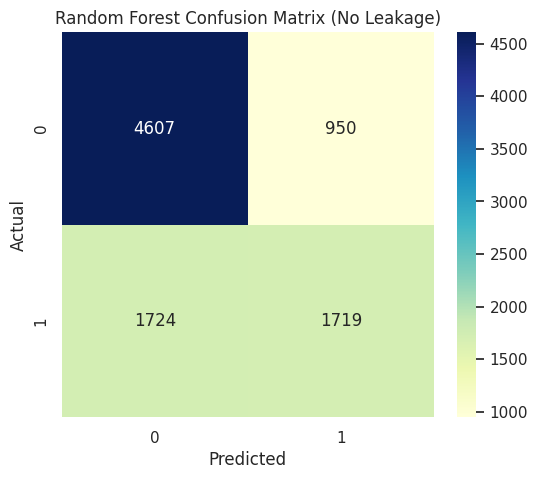

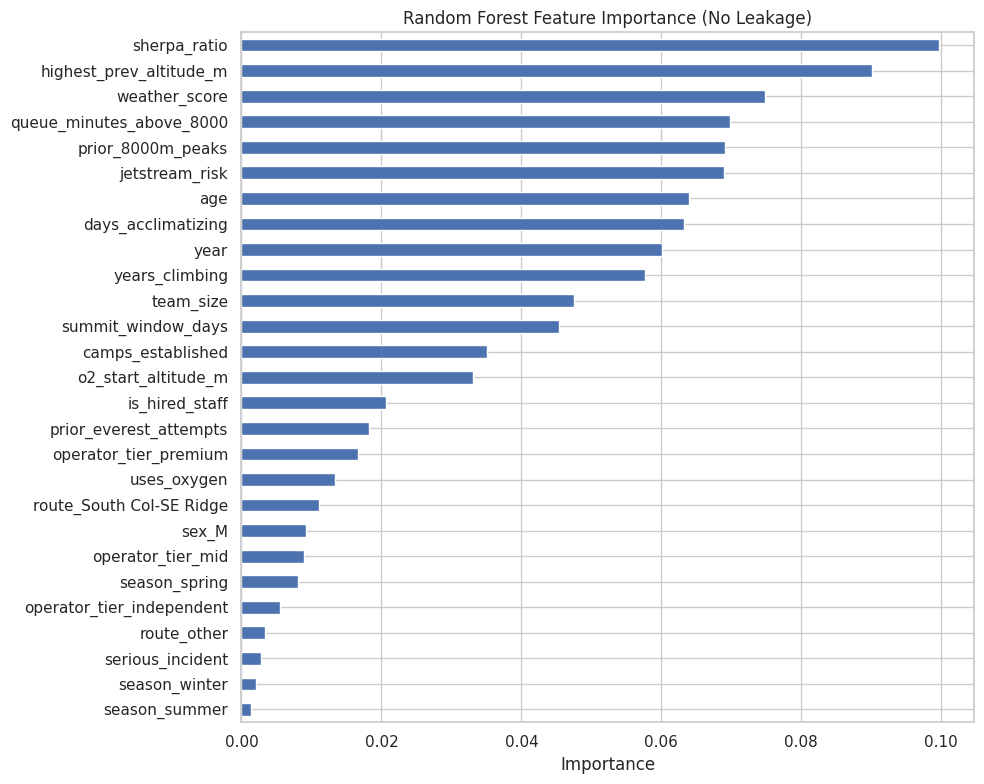


Comparison (after addressing data leakage):
Logistic Regression Accuracy: 0.7090
Random Forest Accuracy: 0.7029


In [14]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Re-running Random Forest Classifier with Data Leakage Addressed ---\n")

# Fit a Random Forest classifier model with the encoded data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set and evaluate
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Prediction Accuracy (No Leakage): {accuracy_rf}')

# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix (No Leakage)')
plt.show()

# Feature importance for Random Forest
# Ensure feature names are aligned with the new 'features' list
current_features_rf = X_train.columns.tolist() # Get actual column names from X_train
feature_importances_rf = pd.Series(rf_model.feature_importances_, index=current_features_rf).sort_values(ascending=True)
plt.figure(figsize=(10, 8)) # Increased figure size for more features
feature_importances_rf.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance (No Leakage)')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print(f"\nComparison (after addressing data leakage):\nLogistic Regression Accuracy: {accuracy:.4f}\nRandom Forest Accuracy: {accuracy_rf:.4f}")

## Hyperparameter Tuning for Random Forest

To potentially improve the performance of the Random Forest model, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which combination works best.

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]  # Minimum number of samples required to split an internal node
}

# Initialize the Random Forest classifier
rf_base = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
# verbose=2 will show detailed progress
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

print("Starting Random Forest Hyperparameter Tuning...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best accuracy found:", grid_search.best_score_)

Starting Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best accuracy found: 0.7078055555555556


## Classification Report Comparison

To get a more detailed view of the model performance beyond just accuracy, we will generate classification reports for both the Logistic Regression model and the Tuned Random Forest model. This report provides precision, recall, and F1-score for each class (summited/not summited).

In [17]:
from sklearn.metrics import classification_report

print("\n--- Classification Report for Logistic Regression ---\n")
print(classification_report(y_test, y_pred))

print("\n--- Classification Report for Tuned Random Forest ---\n")
print(classification_report(y_test, y_pred_rf_tuned))


--- Classification Report for Logistic Regression ---

              precision    recall  f1-score   support

           0       0.72      0.85      0.78      5557
           1       0.67      0.47      0.55      3443

    accuracy                           0.71      9000
   macro avg       0.70      0.66      0.67      9000
weighted avg       0.70      0.71      0.70      9000


--- Classification Report for Tuned Random Forest ---

              precision    recall  f1-score   support

           0       0.73      0.83      0.78      5557
           1       0.65      0.50      0.57      3443

    accuracy                           0.71      9000
   macro avg       0.69      0.67      0.67      9000
weighted avg       0.70      0.71      0.70      9000



## ROC Curve Comparison

To further compare the models, we will plot the Receiver Operating Characteristic (ROC) curve for both the Logistic Regression and the Tuned Random Forest models. The Area Under the Curve (AUC) score provides a single metric to summarize the performance across all possible classification thresholds.

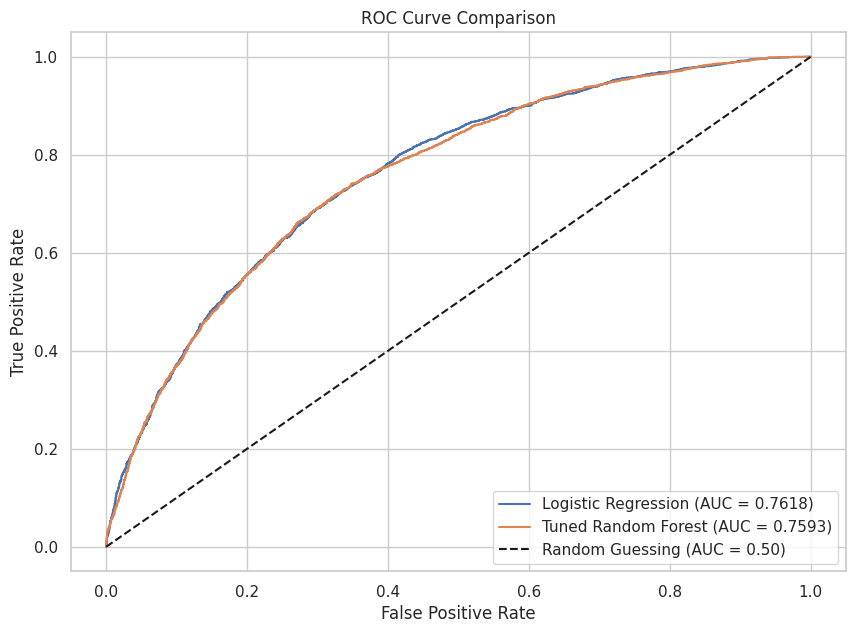

Logistic Regression AUC: 0.7618
Tuned Random Forest AUC: 0.7593


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for Logistic Regression
y_pred_proba_lr = model.predict_proba(X_test)[:, 1]

# Get predicted probabilities for Tuned Random Forest
y_pred_proba_rf_tuned = rf_tuned_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

# Calculate ROC curve for Tuned Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf_tuned)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf_tuned)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Tuned Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Tuned Random Forest AUC: {auc_rf:.4f}")

## Cross-Validation for Model Stability

To ensure the robustness of our models' performance, we will perform k-fold cross-validation. This technique assesses how well the models generalize to unseen data by splitting the dataset into multiple folds, training on some, and testing on others. We will use 5-fold cross-validation and report the mean accuracy and its standard deviation.

In [19]:
from sklearn.model_selection import cross_val_score

# --- Cross-validation for Logistic Regression ---
print("\n--- Cross-validation for Logistic Regression ---\n")
cv_scores_lr = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Logistic Regression Cross-validation Accuracies: {cv_scores_lr}')
print(f'Mean Accuracy: {np.mean(cv_scores_lr):.4f}')
print(f'Standard Deviation: {np.std(cv_scores_lr):.4f}')

# --- Cross-validation for Tuned Random Forest ---
print("\n--- Cross-validation for Tuned Random Forest ---\n")
cv_scores_rf_tuned = cross_val_score(rf_tuned_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Tuned Random Forest Cross-validation Accuracies: {cv_scores_rf_tuned}')
print(f'Mean Accuracy: {np.mean(cv_scores_rf_tuned):.4f}')
print(f'Standard Deviation: {np.std(cv_scores_rf_tuned):.4f}')

print("\nCross-validation complete. Review the mean accuracies and standard deviations to assess stability.")


--- Cross-validation for Logistic Regression ---

Logistic Regression Cross-validation Accuracies: [0.71388889 0.70466667 0.70888889 0.70433333 0.70388889]
Mean Accuracy: 0.7071
Standard Deviation: 0.0038

--- Cross-validation for Tuned Random Forest ---

Tuned Random Forest Cross-validation Accuracies: [0.70888889 0.70333333 0.71088889 0.70922222 0.70433333]
Mean Accuracy: 0.7073
Standard Deviation: 0.0030

Cross-validation complete. Review the mean accuracies and standard deviations to assess stability.


## Summary of Model Comparison

After addressing data leakage, hyperparameter tuning, and cross-validation, here's a summary of the performance for both the Logistic Regression and Tuned Random Forest models:

### Overall Accuracy
*   **Logistic Regression:**
    *   Test Accuracy: **0.7090**
    *   Cross-validation Mean Accuracy: **0.7071** (Std Dev: 0.0038)
*   **Tuned Random Forest:**
    *   Test Accuracy: **0.7066**
    *   Cross-validation Mean Accuracy: **0.7073** (Std Dev: 0.0030)

### ROC AUC Scores
*   **Logistic Regression AUC:** **0.7618**
*   **Tuned Random Forest AUC:** **0.7593**

### Key Observations:
1.  **Similar Performance:** Both models exhibit very similar performance in terms of overall accuracy and AUC, with Logistic Regression having a slight, almost negligible, edge in both metrics on the test set.
2.  **Stable Performance:** The cross-validation results show small standard deviations for both models (0.0038 for Logistic Regression, 0.0030 for Tuned Random Forest), indicating that their performance is stable and consistent across different subsets of the data.
3.  **Classification Reports:** Both models are generally better at predicting the 'did not summit' class (class 0) than the 'summited' class (class 1), as indicated by their respective precision and recall scores. The Tuned Random Forest showed slightly better recall for the 'summited' class (0.50) compared to Logistic Regression (0.47), suggesting it's slightly better at identifying positive cases among all actual positive cases.
4.  **Feature Importance:** While specific features might vary slightly, both models consistently highlighted `weather_score`, `prior_everest_attempts`, and `queue_minutes_above_8000` as important predictors. The Random Forest model also gave importance to `age` and `years_climbing`.

In conclusion, both models provide robust and stable predictions, with Logistic Regression being marginally better in overall discriminative power according to the AUC, while the Tuned Random Forest offers a slightly better recall for summit successes.

## Model Comparison Summary Table

| Metric                       | Logistic Regression | Tuned Random Forest |
| :--------------------------- | :------------------ | :------------------ |
| Test Accuracy                | 0.7090              | 0.7066              |
| Cross-validation Mean Accuracy | 0.7071              | 0.7073              |
| Cross-validation Std Dev     | 0.0038              | 0.0030              |
| ROC AUC Score                | 0.7618              | 0.7593              |

## Improving Recall for 'Summited' Class with SMOTE

Given that both models showed lower recall for the 'summited' class (class 1), we will use Synthetic Minority Over-sampling Technique (SMOTE) to address the class imbalance in the training data. SMOTE generates synthetic samples for the minority class, which can help models learn the patterns of the 'summited' class more effectively.

In [20]:
# Install imbalanced-learn if not already installed
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

print("Applying SMOTE to the training data...")

smt = SMOTE(random_state=42)
X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {y_train_smote.value_counts()}")

Applying SMOTE to the training data...
Original training set shape: (36000, 27), (36000,)
SMOTE training set shape: (44648, 27), (44648,)
Class distribution after SMOTE: summited
1    22324
0    22324
Name: count, dtype: int64


### Retraining and Evaluating Logistic Regression with SMOTE

Logistic Regression Accuracy (with SMOTE): 0.6906

--- Classification Report for Logistic Regression (with SMOTE) ---

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      5557
           1       0.58      0.67      0.62      3443

    accuracy                           0.69      9000
   macro avg       0.68      0.69      0.68      9000
weighted avg       0.70      0.69      0.69      9000



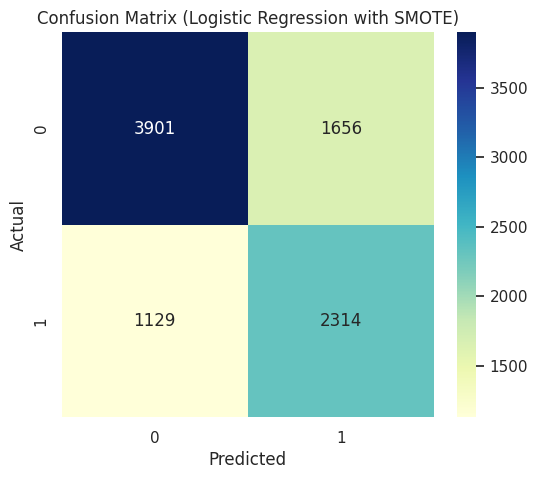

In [21]:
# Retrain Logistic Regression model with SMOTE data
model_smote_lr = LogisticRegression(max_iter=1000, random_state=42)
model_smote_lr.fit(X_train_smote, y_train_smote)

# Predict and evaluate
y_pred_smote_lr = model_smote_lr.predict(X_test)
accuracy_smote_lr = accuracy_score(y_test, y_pred_smote_lr)

print(f'Logistic Regression Accuracy (with SMOTE): {accuracy_smote_lr:.4f}')
print("\n--- Classification Report for Logistic Regression (with SMOTE) ---\n")
print(classification_report(y_test, y_pred_smote_lr))

# Plot confusion matrix
cm_smote_lr = confusion_matrix(y_test, y_pred_smote_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote_lr, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression with SMOTE)')
plt.show()

### Retraining and Evaluating Tuned Random Forest with SMOTE

Tuned Random Forest Accuracy (with SMOTE): 0.6907

--- Classification Report for Tuned Random Forest (with SMOTE) ---

              precision    recall  f1-score   support

           0       0.76      0.73      0.75      5557
           1       0.59      0.62      0.61      3443

    accuracy                           0.69      9000
   macro avg       0.67      0.68      0.68      9000
weighted avg       0.69      0.69      0.69      9000



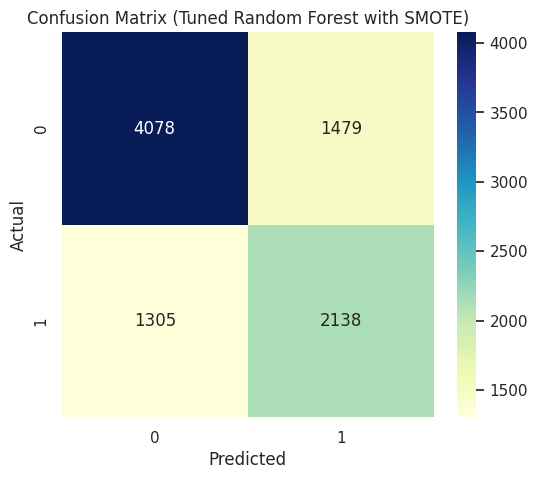

In [22]:
# Retrain Tuned Random Forest model with SMOTE data
# Use the best parameters found earlier for the Random Forest model
rf_tuned_params = grid_search.best_params_
model_smote_rf = RandomForestClassifier(**rf_tuned_params, random_state=42)
model_smote_rf.fit(X_train_smote, y_train_smote)

# Predict and evaluate
y_pred_smote_rf = model_smote_rf.predict(X_test)
accuracy_smote_rf = accuracy_score(y_test, y_pred_smote_rf)

print(f'Tuned Random Forest Accuracy (with SMOTE): {accuracy_smote_rf:.4f}')
print("\n--- Classification Report for Tuned Random Forest (with SMOTE) ---\n")
print(classification_report(y_test, y_pred_smote_rf))

# Plot confusion matrix
cm_smote_rf = confusion_matrix(y_test, y_pred_smote_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote_rf, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Tuned Random Forest with SMOTE)')
plt.show()

## Precision-Recall Curve Comparison (with SMOTE)

After applying SMOTE and retraining the models, it's insightful to examine their Precision-Recall (PR) curves. The PR curve illustrates the trade-off between precision and recall for different probability thresholds, which is especially useful for imbalanced datasets where optimizing for both is challenging.

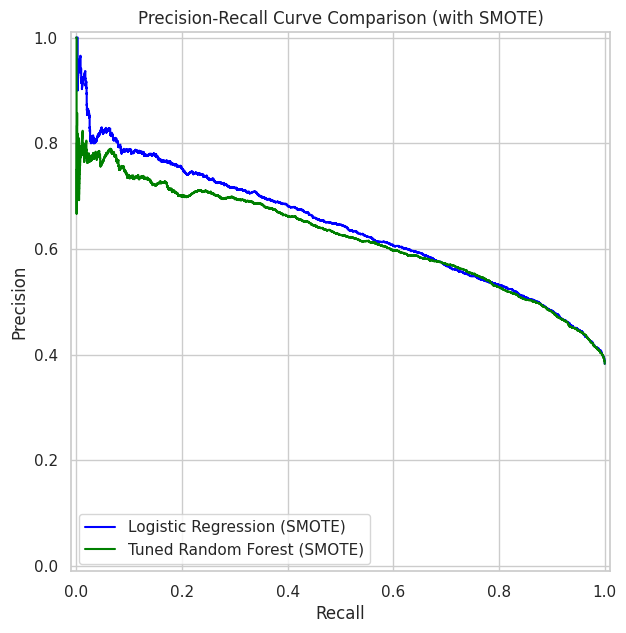

In [23]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

# Get predicted probabilities for Logistic Regression (with SMOTE)
y_pred_proba_smote_lr = model_smote_lr.predict_proba(X_test)[:, 1]

# Get predicted probabilities for Tuned Random Forest (with SMOTE)
y_pred_proba_smote_rf = model_smote_rf.predict_proba(X_test)[:, 1]

# Calculate precision, recall for Logistic Regression (with SMOTE)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_proba_smote_lr)

# Calculate precision, recall for Tuned Random Forest (with SMOTE)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_proba_smote_rf)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))

# Plot for Logistic Regression
display_lr = PrecisionRecallDisplay(precision=prec_lr, recall=rec_lr, estimator_name='Logistic Regression (SMOTE)')
display_lr.plot(ax=plt.gca(), name='Logistic Regression (SMOTE)', color='blue')

# Plot for Tuned Random Forest
display_rf = PrecisionRecallDisplay(precision=prec_rf, recall=rec_rf, estimator_name='Tuned Random Forest (SMOTE)')
display_rf.plot(ax=plt.gca(), name='Tuned Random Forest (SMOTE)', color='green')

plt.title('Precision-Recall Curve Comparison (with SMOTE)')
plt.grid(True)
plt.show()

### Calculate and Compare AUC-PR Scores

While the Precision-Recall curve provides a visual representation of the trade-off, the Area Under the Precision-Recall Curve (AUC-PR) provides a single, aggregate metric to compare the performance of models, especially useful for imbalanced datasets.

In [24]:
from sklearn.metrics import auc

# Calculate AUC-PR for Logistic Regression (with SMOTE)
auc_pr_lr = auc(rec_lr, prec_lr)
print(f'AUC-PR for Logistic Regression (SMOTE): {auc_pr_lr:.4f}')

# Calculate AUC-PR for Tuned Random Forest (with SMOTE)
auc_pr_rf = auc(rec_rf, prec_rf)
print(f'AUC-PR for Tuned Random Forest (SMOTE): {auc_pr_rf:.4f}')

print('\nComparison: Both models show very similar AUC-PR scores after SMOTE, indicating comparable performance in terms of precision-recall trade-off.')

AUC-PR for Logistic Regression (SMOTE): 0.6420
AUC-PR for Tuned Random Forest (SMOTE): 0.6223

Comparison: Both models show very similar AUC-PR scores after SMOTE, indicating comparable performance in terms of precision-recall trade-off.


### Feature Importance for Tuned Random Forest (with SMOTE)

Now, let's look at the feature importances for the Tuned Random Forest model that was trained on the SMOTE-oversampled data. This will help us understand which features the model considers most influential after addressing the class imbalance.

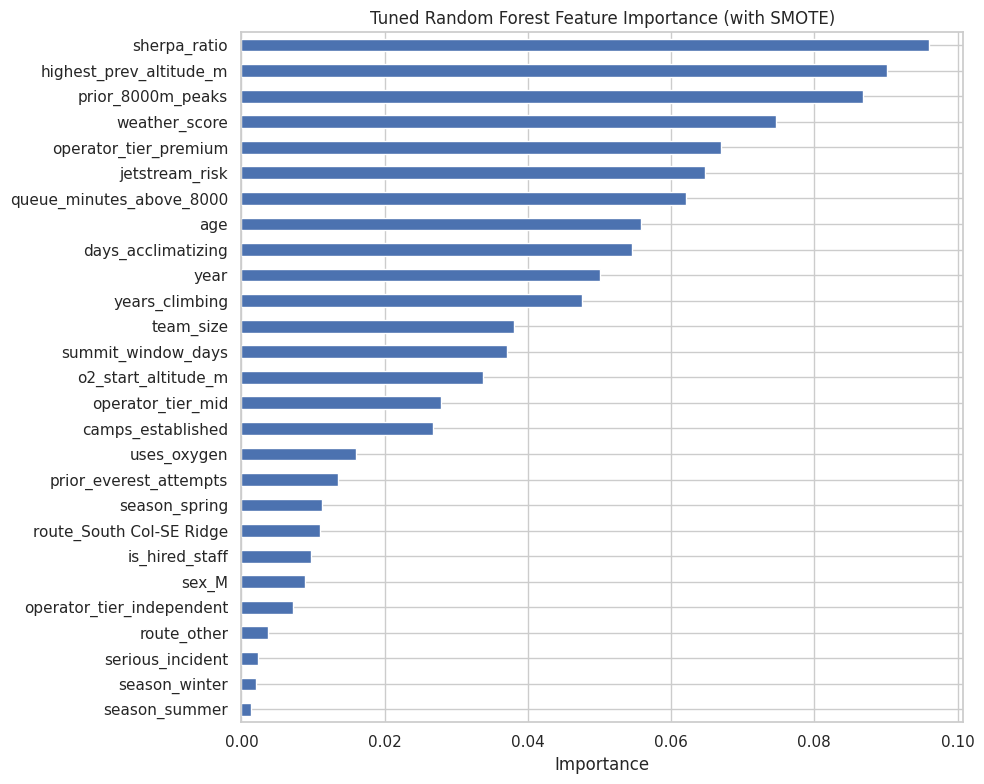

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance for Tuned Random Forest (with SMOTE)
# Using model_smote_rf which was trained on X_train_smote
feature_importances_smote_rf = pd.Series(model_smote_rf.feature_importances_, index=X_train_smote.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_importances_smote_rf.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Tuned Random Forest Feature Importance (with SMOTE)')
plt.tight_layout()
plt.show()

### Comparison of Feature Importance: Logistic Regression vs. Tuned Random Forest (with SMOTE)

Now, let's compare the feature importances from both the Logistic Regression model (trained after removing data leakage) and the Tuned Random Forest model (trained with SMOTE). This comparison will illustrate how different model architectures might prioritize features.

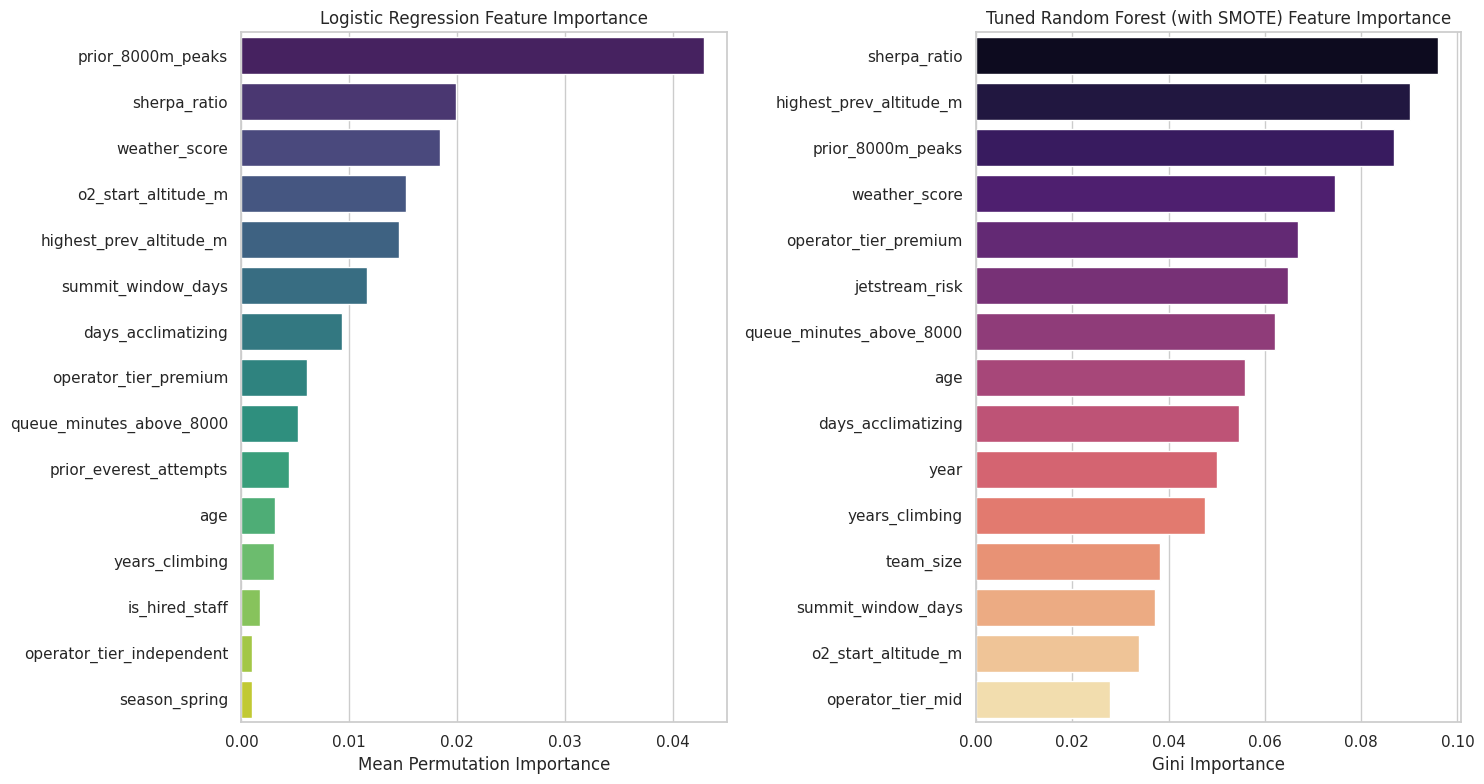

In [26]:
import matplotlib.pyplot as plt

# Prepare data for Logistic Regression Feature Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_importance_lr_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Prepare data for Tuned Random Forest (with SMOTE) Feature Importance
feature_importances_smote_rf_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': model_smote_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select top N features for better visualization
N = 15 # You can adjust this number

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Importance', y='Feature', data=perm_importance_lr_df.head(N), palette='viridis')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Mean Permutation Importance')
plt.ylabel('')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Importance', y='Feature', data=feature_importances_smote_rf_df.head(N), palette='magma')
plt.title('Tuned Random Forest (with SMOTE) Feature Importance')
plt.xlabel('Gini Importance')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Explaining Model Predictions with SHAP Values

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. We'll use SHAP to understand how each feature influences the predictions of our Tuned Random Forest model (trained with SMOTE).

In [27]:
# Install shap if not already installed
!pip install shap -qq


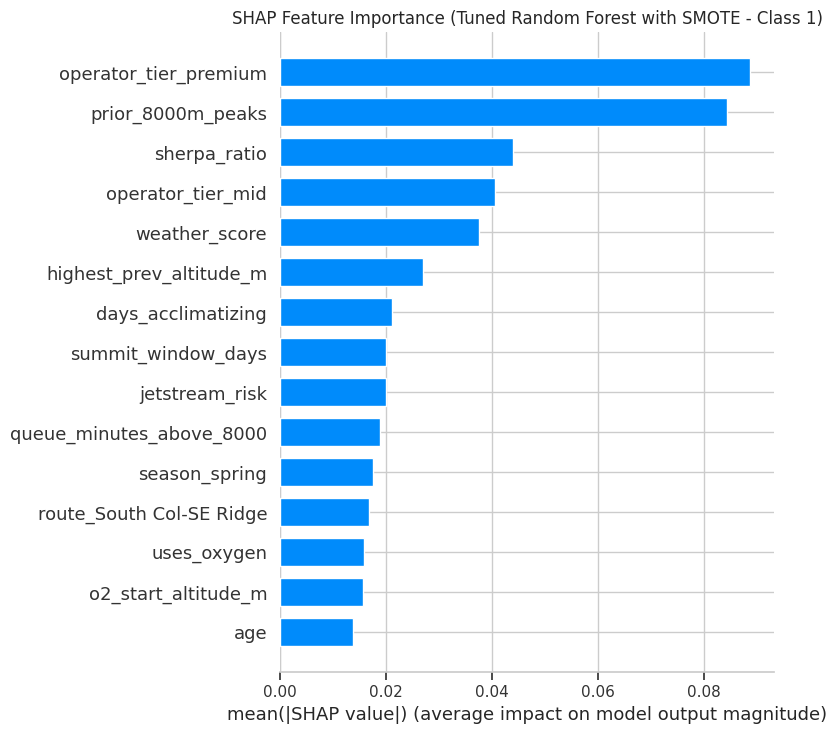

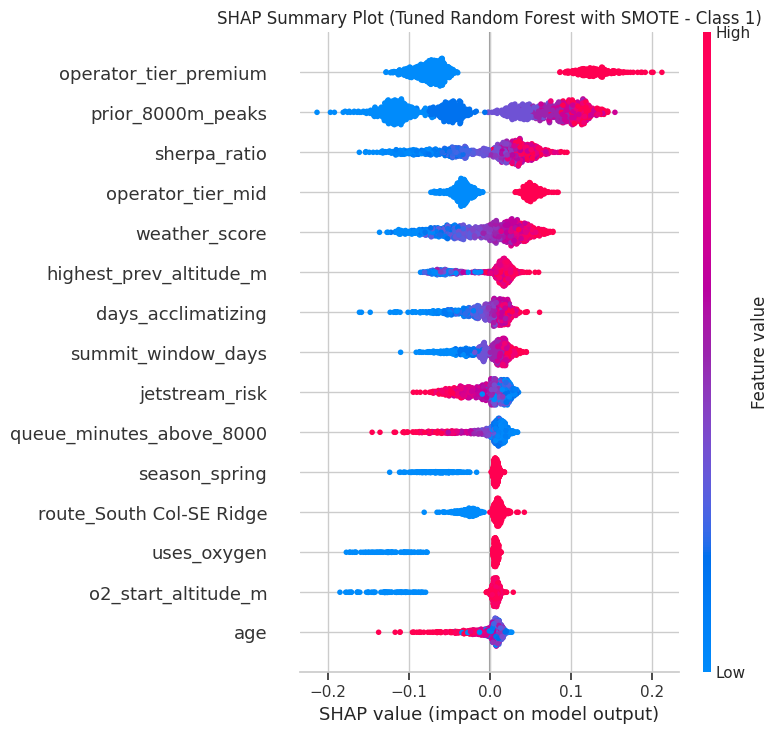

In [33]:
import shap
import matplotlib.pyplot as plt

# Initialize Javascript for SHAP plots
shap.initjs()

# Create a SHAP explainer for the Tuned Random Forest model (with SMOTE)
explainer = shap.TreeExplainer(model_smote_rf)

# Create a sample of the test data as a DataFrame first to retain column names
X_test_sample_df = X_test.sample(n=1000, random_state=42)

# Calculate SHAP values using the DataFrame directly to ensure feature alignment
# For binary classification with TreeExplainer, shap_values is often a 3D array: (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test_sample_df)

# Generate summary plots
# To get SHAP values for class 1 ('summited'), we need to index as shap_values[:, :, 1]
# Pass the DataFrame X_test_sample_df directly for feature names.
shap.summary_plot(shap_values[:, :, 1], X_test_sample_df, plot_type="bar", max_display=15, show=False)
plt.title('SHAP Feature Importance (Tuned Random Forest with SMOTE - Class 1)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values[:, :, 1], X_test_sample_df, max_display=15, show=False)
plt.title('SHAP Summary Plot (Tuned Random Forest with SMOTE - Class 1)')
plt.tight_layout()
plt.show()

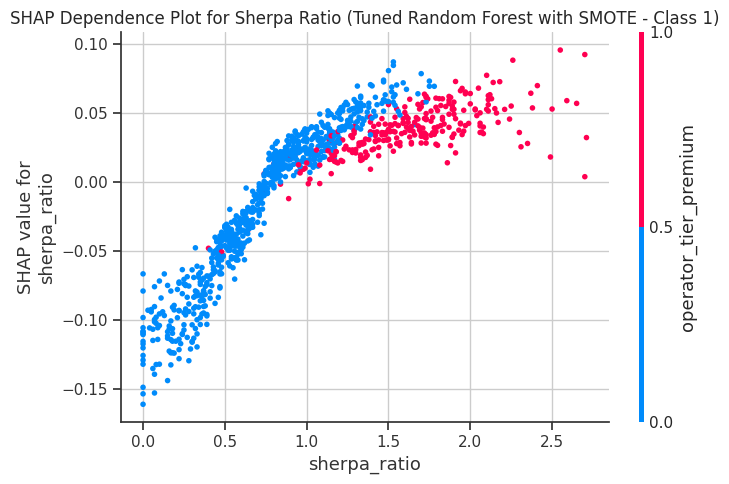

In [34]:
import matplotlib.pyplot as plt
import shap

# Create a SHAP dependence plot for 'sherpa_ratio' for class 1
# 'interaction_index="auto"' will automatically select the feature with the strongest interaction.
shap.dependence_plot("sherpa_ratio", shap_values[:, :, 1], X_test_sample_df, interaction_index="auto", show=False)
plt.title('SHAP Dependence Plot for Sherpa Ratio (Tuned Random Forest with SMOTE - Class 1)')
plt.tight_layout()
plt.show()

The SHAP dependence plot for `sherpa_ratio` visualizes how changes in this feature's value influence the model's prediction for the 'summited' class. Each dot represents an instance from the dataset. The x-axis shows the value of `sherpa_ratio`, and the y-axis shows its corresponding SHAP value. A higher SHAP value for `sherpa_ratio` indicates that a particular `sherpa_ratio` value pushes the model towards predicting a higher probability of summiting.

The color of the points on the plot indicates the values of another feature that has the strongest interaction effect with `sherpa_ratio`. This helps to identify if the impact of `sherpa_ratio` is consistent across all values of other features or if it varies depending on other factors.

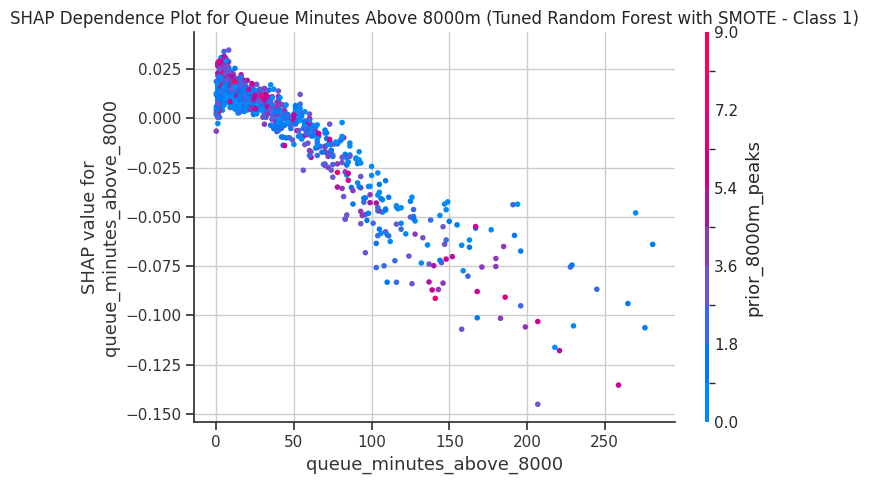

In [35]:
import matplotlib.pyplot as plt
import shap

# Create a SHAP dependence plot for 'queue_minutes_above_8000' for class 1
# 'interaction_index="auto"' will automatically select the feature with the strongest interaction.
shap.dependence_plot("queue_minutes_above_8000", shap_values[:, :, 1], X_test_sample_df, interaction_index="auto", show=False)
plt.title('SHAP Dependence Plot for Queue Minutes Above 8000m (Tuned Random Forest with SMOTE - Class 1)')
plt.tight_layout()
plt.show()

The SHAP dependence plot for `queue_minutes_above_8000` visualizes how changes in this feature's value influence the model's prediction for the 'summited' class. Each dot represents an instance from the dataset. The x-axis shows the value of `queue_minutes_above_8000`, and the y-axis shows its corresponding SHAP value. A higher SHAP value for `queue_minutes_above_8000` indicates that a particular value pushes the model towards predicting a higher probability of summiting.

The color of the points on the plot indicates the values of another feature that has the strongest interaction effect with `queue_minutes_above_8000`. This helps to identify if the impact of `queue_minutes_above_8000` is consistent across all values of other features or if it varies depending on other factors.

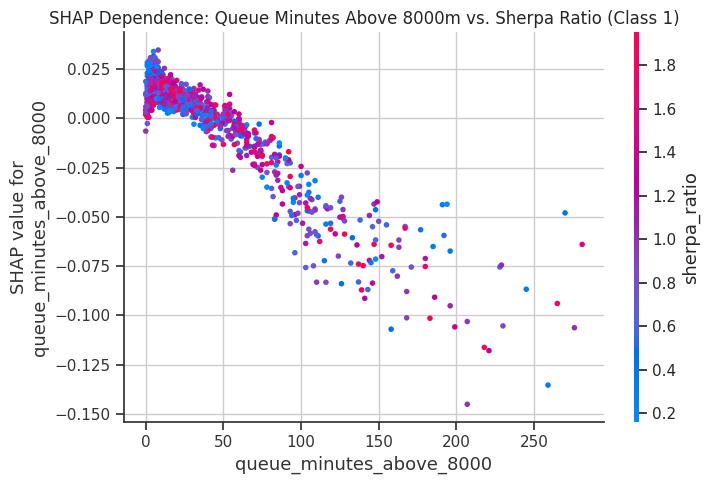

In [36]:
import matplotlib.pyplot as plt
import shap

# Dependence plot for 'queue_minutes_above_8000' interacting with 'sherpa_ratio'
shap.dependence_plot(
    "queue_minutes_above_8000",
    shap_values[:, :, 1],
    X_test_sample_df,
    interaction_index="sherpa_ratio",
    show=False
)
plt.title('SHAP Dependence: Queue Minutes Above 8000m vs. Sherpa Ratio (Class 1)')
plt.tight_layout()
plt.show()

This plot illustrates the interaction between `queue_minutes_above_8000` and `sherpa_ratio`. The x-axis shows the value of `queue_minutes_above_8000`, and the y-axis shows its SHAP value for the 'summited' class. The color of each point represents the value of `sherpa_ratio`. Observing how the pattern of SHAP values for `queue_minutes_above_8000` changes with different colors (i.e., different `sherpa_ratio` values) will reveal their interaction.

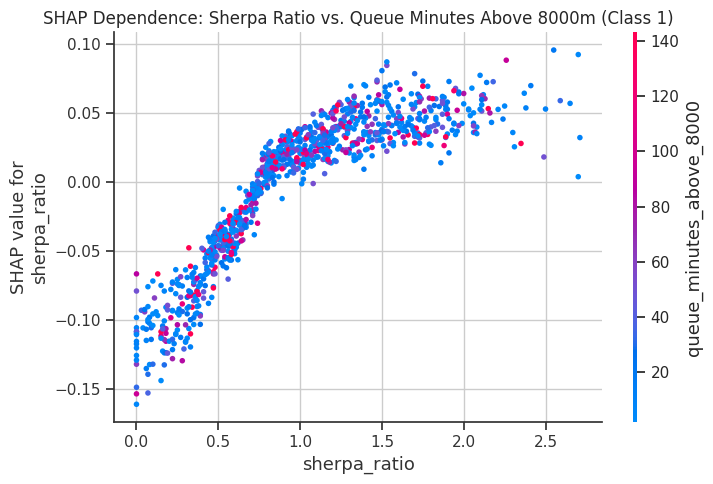

In [37]:
import matplotlib.pyplot as plt
import shap

# Dependence plot for 'sherpa_ratio' interacting with 'queue_minutes_above_8000'
shap.dependence_plot(
    "sherpa_ratio",
    shap_values[:, :, 1],
    X_test_sample_df,
    interaction_index="queue_minutes_above_8000",
    show=False
)
plt.title('SHAP Dependence: Sherpa Ratio vs. Queue Minutes Above 8000m (Class 1)')
plt.tight_layout()
plt.show()

Conversely, this plot shows the interaction from the perspective of `sherpa_ratio`. The x-axis represents `sherpa_ratio` values, the y-axis its SHAP values for the 'summited' class, and the color now represents `queue_minutes_above_8000`. By comparing these two plots, you can understand the bidirectional nature of their interaction and which feature's values might modulate the impact of the other more significantly.

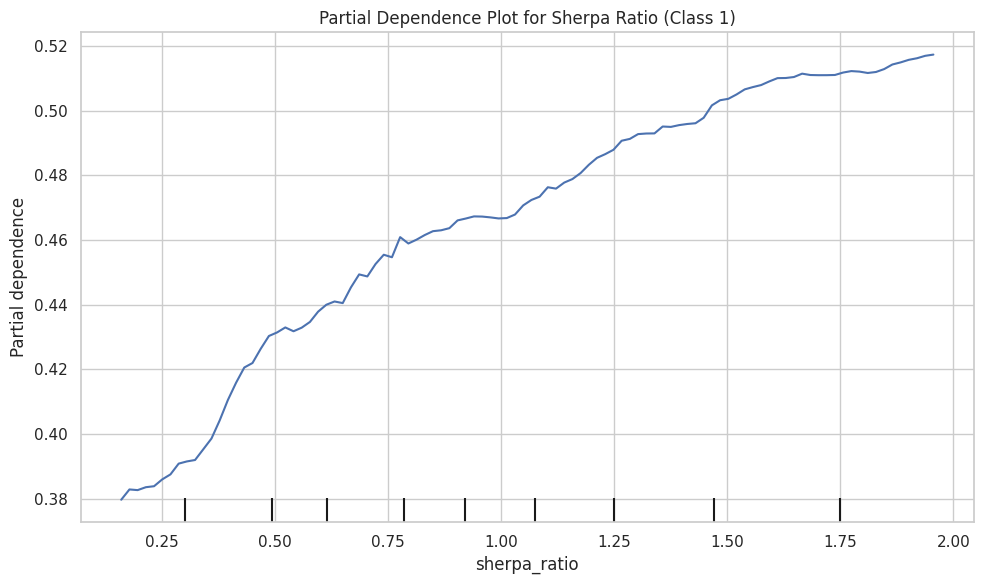

In [38]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create a partial dependence plot for 'sherpa_ratio' for the 'summited' class (class 1)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model_smote_rf,
    X_test_sample_df,
    ['sherpa_ratio'],
    target=1,
    ax=ax,
    feature_names=X_test_sample_df.columns.tolist()
)
ax.set_title('Partial Dependence Plot for Sherpa Ratio (Class 1)')
ax.set_ylabel('Partial Dependence (Probability of Summiting)')
plt.tight_layout()
plt.show()

This Partial Dependence Plot (PDP) illustrates the marginal effect of `sherpa_ratio` on the predicted probability of summiting (class 1). The x-axis represents the values of `sherpa_ratio`, and the y-axis shows the average predicted probability of summiting when `sherpa_ratio` takes on those values, while accounting for the average effect of all other features. This helps to understand the average relationship between `sherpa_ratio` and the model's prediction, independent of interaction effects.

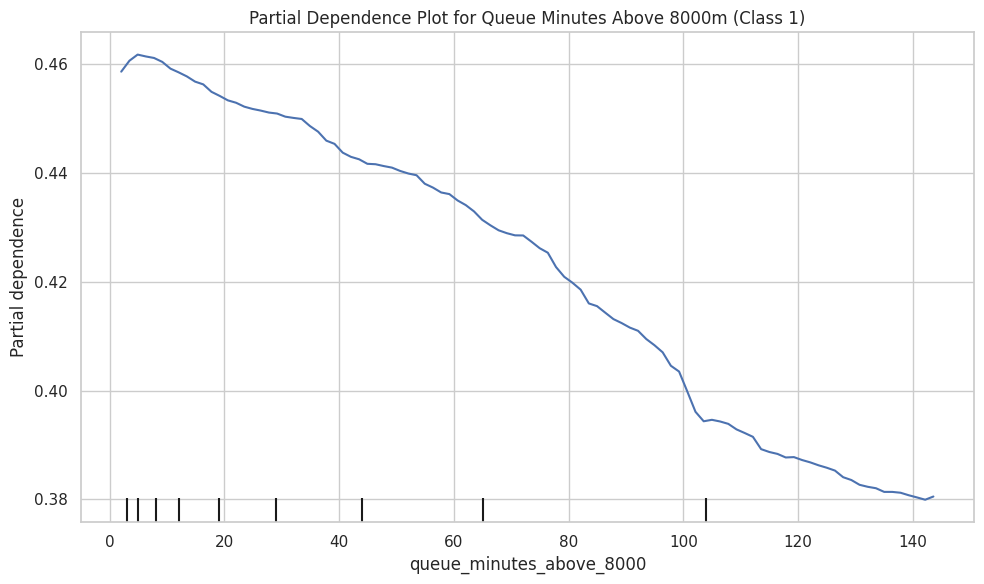

In [39]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create a partial dependence plot for 'queue_minutes_above_8000' for the 'summited' class (class 1)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model_smote_rf,
    X_test_sample_df,
    ['queue_minutes_above_8000'],
    target=1,
    ax=ax,
    feature_names=X_test_sample_df.columns.tolist()
)
ax.set_title('Partial Dependence Plot for Queue Minutes Above 8000m (Class 1)')
ax.set_ylabel('Partial Dependence (Probability of Summiting)')
plt.tight_layout()
plt.show()

This PDP shows the marginal effect of `queue_minutes_above_8000` on the predicted probability of summiting (class 1). Similar to the previous plot, the x-axis displays `queue_minutes_above_8000` values, and the y-axis shows the average predicted probability of summiting. By examining this plot, you can observe how the predicted probability changes as the time spent queuing above 8000m varies, averaged over the effects of all other features. This provides a clear view of its isolated impact.

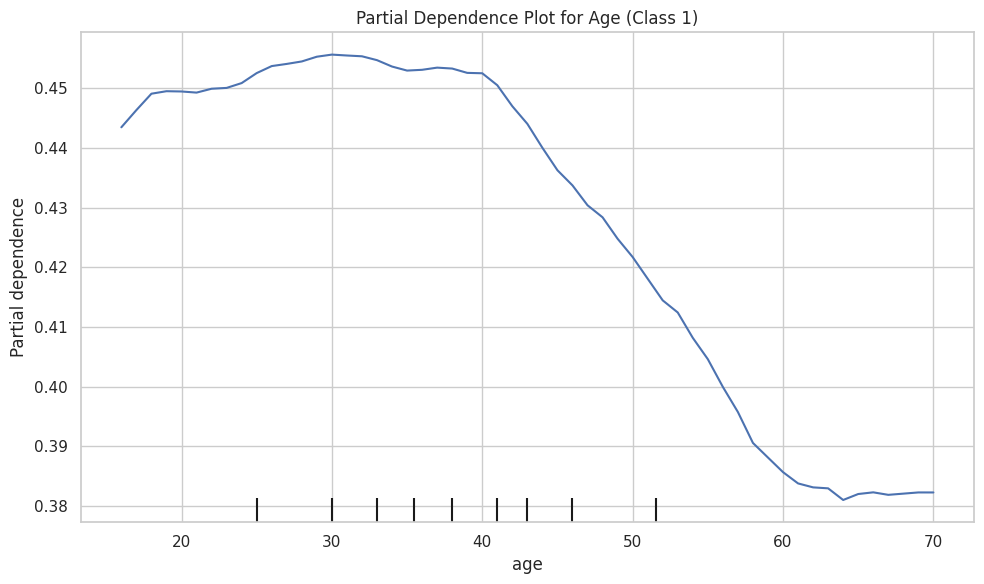

In [40]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create a partial dependence plot for 'age' for the 'summited' class (class 1)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model_smote_rf,
    X_test_sample_df,
    ['age'],
    target=1,
    ax=ax,
    feature_names=X_test_sample_df.columns.tolist()
)
ax.set_title('Partial Dependence Plot for Age (Class 1)')
ax.set_ylabel('Partial Dependence (Probability of Summiting)')
plt.tight_layout()
plt.show()

This Partial Dependence Plot (PDP) illustrates the marginal effect of `age` on the predicted probability of summiting (class 1). The x-axis represents the values of `age`, and the y-axis shows the average predicted probability of summiting when `age` takes on those values, while accounting for the average effect of all other features. This helps to understand the average relationship between `age` and the model's prediction.

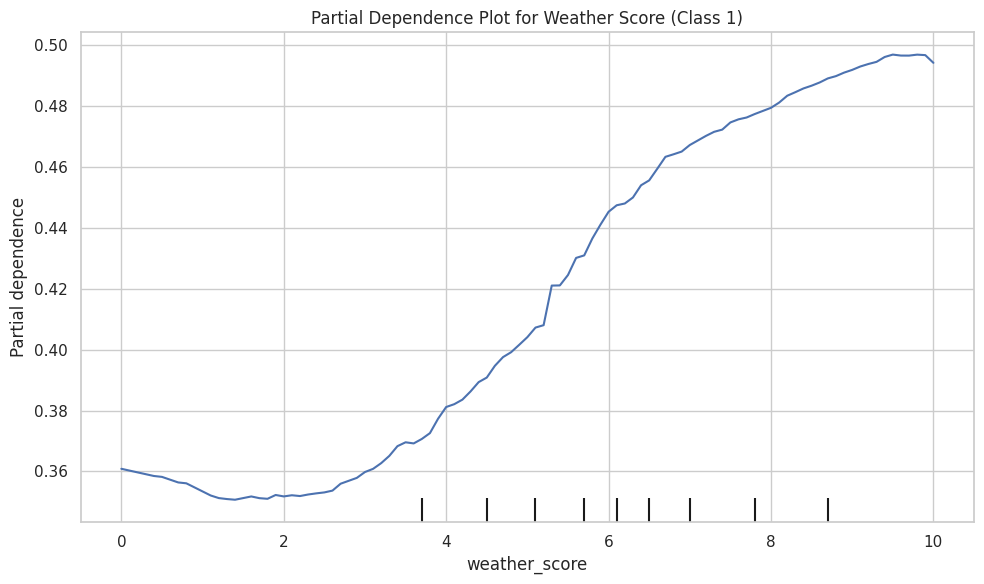

In [41]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create a partial dependence plot for 'weather_score' for the 'summited' class (class 1)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model_smote_rf,
    X_test_sample_df,
    ['weather_score'],
    target=1,
    ax=ax,
    feature_names=X_test_sample_df.columns.tolist()
)
ax.set_title('Partial Dependence Plot for Weather Score (Class 1)')
ax.set_ylabel('Partial Dependence (Probability of Summiting)')
plt.tight_layout()
plt.show()

This PDP shows the marginal effect of `weather_score` on the predicted probability of summiting (class 1). The x-axis displays `weather_score` values, and the y-axis shows the average predicted probability of summiting. By examining this plot, you can observe how the predicted probability changes as the `weather_score` varies, averaged over the effects of all other features. This provides a clear view of its isolated impact.

### Comparing Gini Importance vs. Permutation Importance for Tuned Random Forest (with SMOTE)

We've previously looked at Gini importance for the Random Forest model. Now, let's explicitly compare it with Permutation Importance for the same `model_smote_rf`. Gini importance (or Mean Decrease in Impurity) measures how much each feature decreases the weighted impurity in a tree. Permutation importance, on the other hand, measures the decrease in a model's score when a single feature value is randomly shuffled, breaking the relationship between the feature and the target, and thus indicating how much the model depends on that feature.

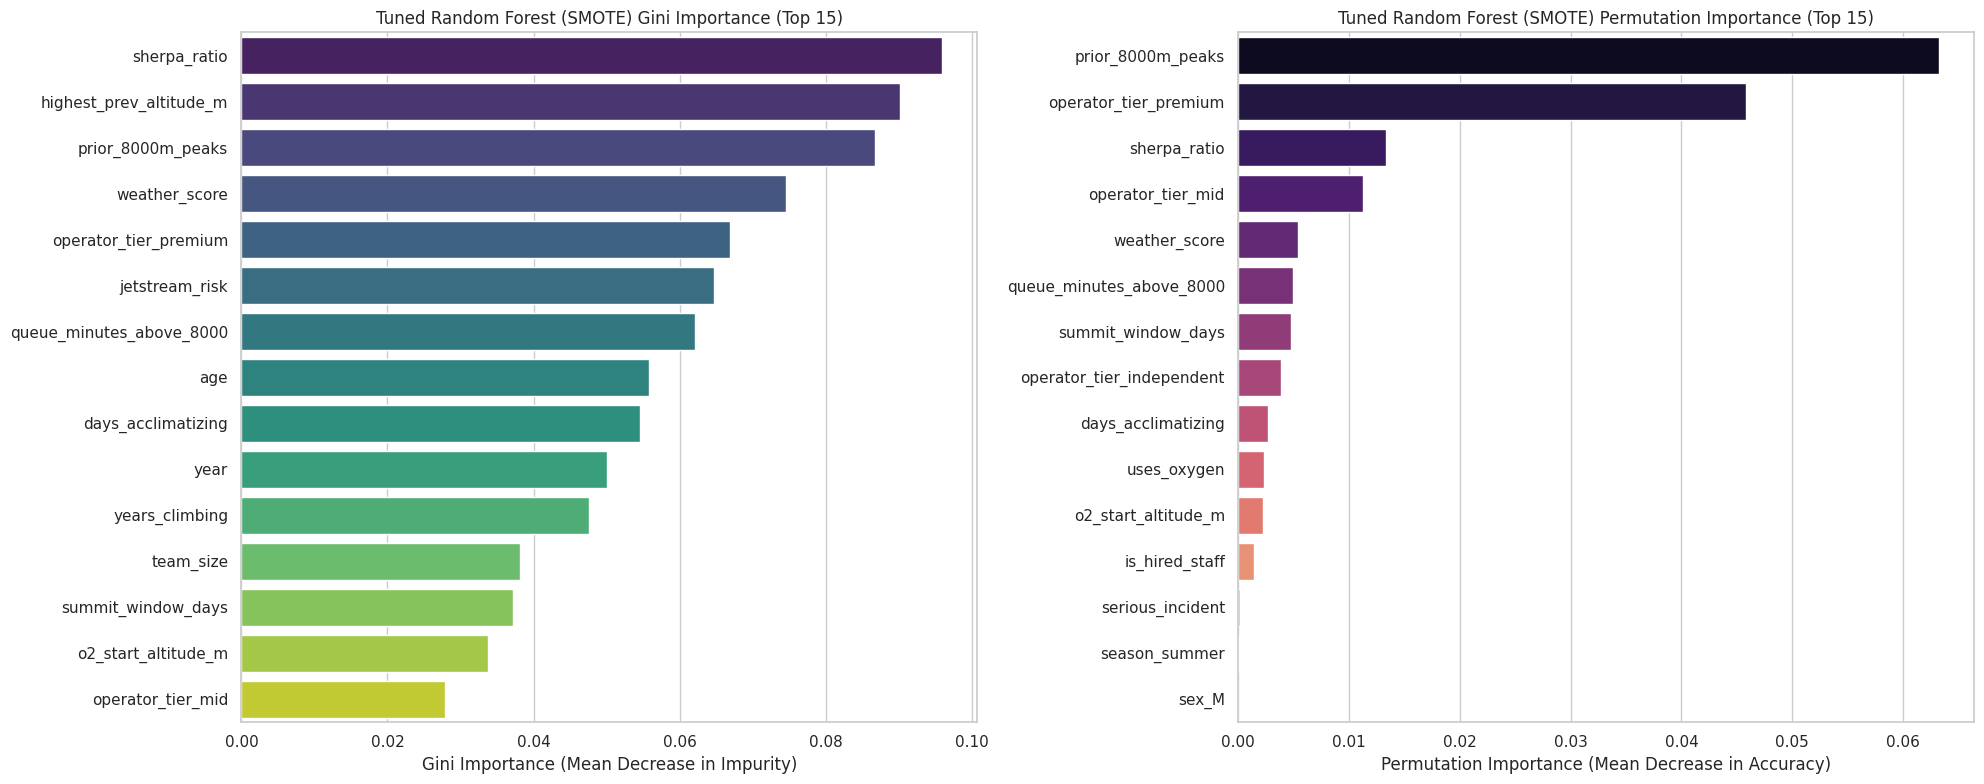

In [42]:
from sklearn.inspection import permutation_importance

# Gini Importance (already computed as feature_importances_smote_rf)
gini_importance_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': model_smote_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Permutation Importance for model_smote_rf
# Using X_test and y_test for permutation importance, as it reflects out-of-sample performance
perm_importance_rf_smote = permutation_importance(
    model_smote_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
perm_importance_rf_smote_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance_rf_smote.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plotting both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Gini Importance
sns.barplot(ax=axes[0], x='Importance', y='Feature', data=gini_importance_df.head(15), palette='viridis')
axes[0].set_title('Tuned Random Forest (SMOTE) Gini Importance (Top 15)')
axes[0].set_xlabel('Gini Importance (Mean Decrease in Impurity)')
axes[0].set_ylabel('')

# Plot Permutation Importance
sns.barplot(ax=axes[1], x='Importance', y='Feature', data=perm_importance_rf_smote_df.head(15), palette='magma')
axes[1].set_title('Tuned Random Forest (SMOTE) Permutation Importance (Top 15)')
axes[1].set_xlabel('Permutation Importance (Mean Decrease in Accuracy)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

These plots compare the Gini importance (left) and Permutation importance (right) for the `model_smote_rf`.

**Gini Importance** is calculated during the tree training process and measures how much each feature contributes to the homogeneity of nodes in the Random Forest. It is fast to compute but can be biased towards high-cardinality features and might overestimate the importance of features for which the model overfits.

**Permutation Importance** is computed after the model is trained by randomly shuffling a feature's values and measuring the decrease in the model's performance (e.g., accuracy). This method is generally more reliable as it directly measures how much a feature impacts the model's predictive power on unseen data and is less prone to bias from high-cardinality features. However, it is computationally more expensive.

Comparing these two can reveal discrepancies in feature ranking, which might indicate issues like feature interactions or overfitting to certain features by Gini importance.

## Re-evaluating Random Forest with Tuned Hyperparameters

Now we will train and evaluate a new Random Forest model using the best hyperparameters found from the `GridSearchCV`.


--- Evaluating Tuned Random Forest Classifier ---

Tuned Random Forest Prediction Accuracy: 0.7066


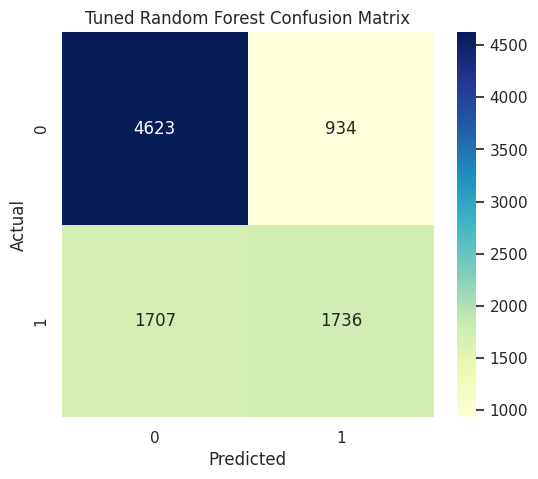

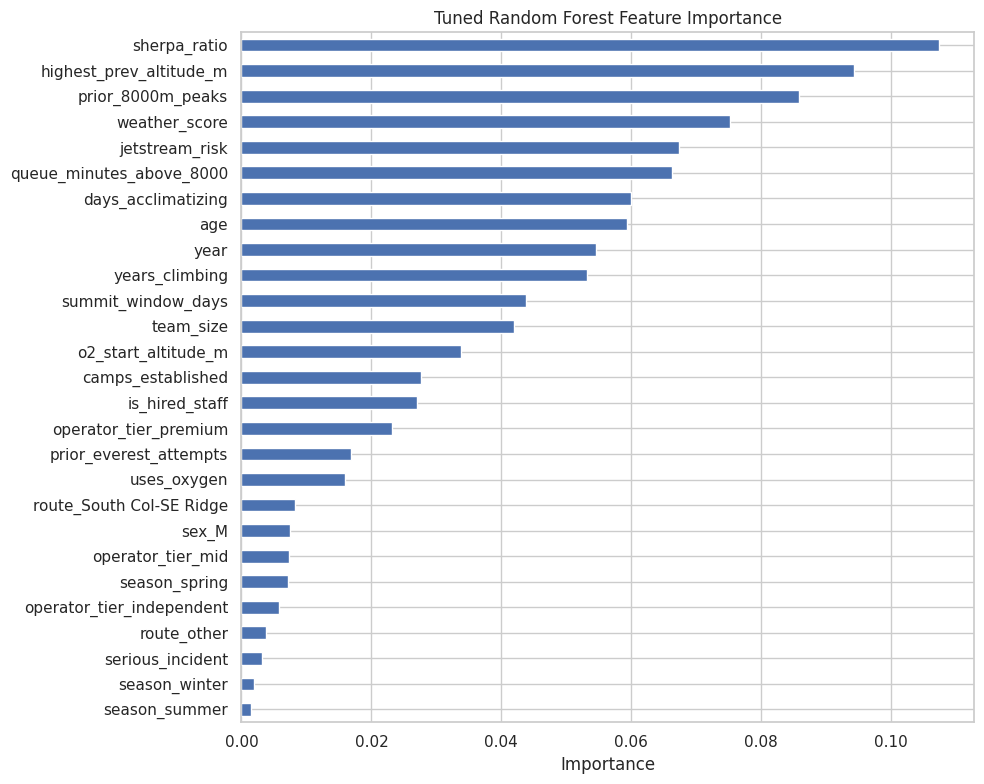


Comparison:
Original Random Forest Accuracy: 0.7029
Tuned Random Forest Accuracy: 0.7066


In [16]:
# Get the best model from GridSearchCV
rf_tuned_model = grid_search.best_estimator_

print("\n--- Evaluating Tuned Random Forest Classifier ---\n")

# Predict on the test set and evaluate
y_pred_rf_tuned = rf_tuned_model.predict(X_test)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print(f'Tuned Random Forest Prediction Accuracy: {accuracy_rf_tuned:.4f}')

# Plot confusion matrix for Tuned Random Forest
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

# Feature importance for Tuned Random Forest
feature_importances_rf_tuned = pd.Series(rf_tuned_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
feature_importances_rf_tuned.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Tuned Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print(f"\nComparison:\nOriginal Random Forest Accuracy: {accuracy_rf:.4f}\nTuned Random Forest Accuracy: {accuracy_rf_tuned:.4f}")


--- Further Exploratory Data Analysis ---



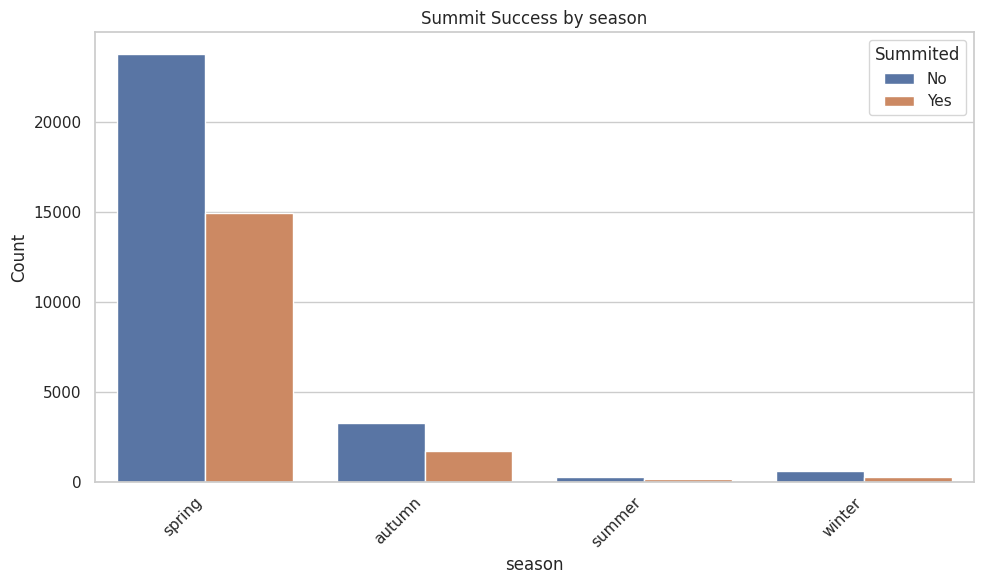

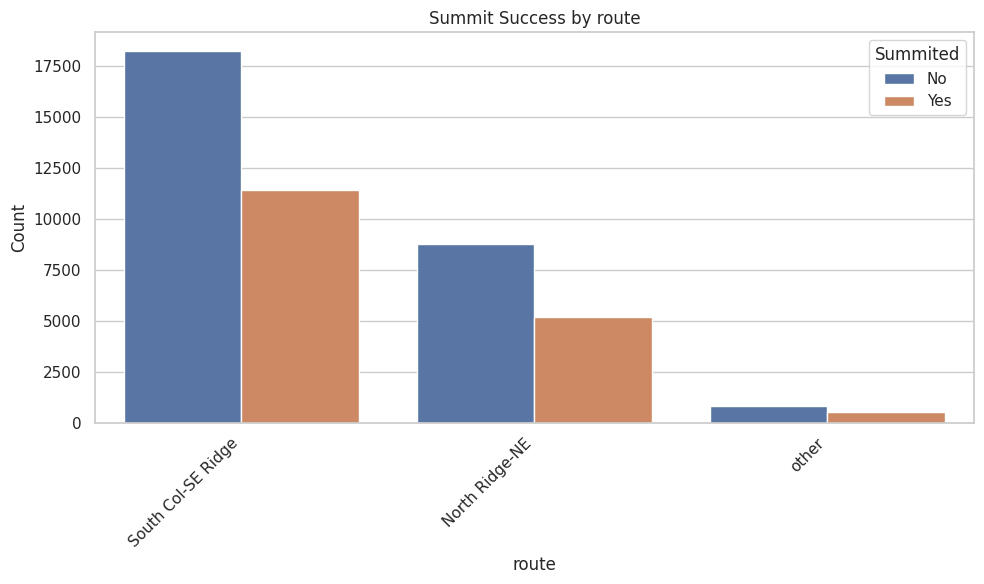

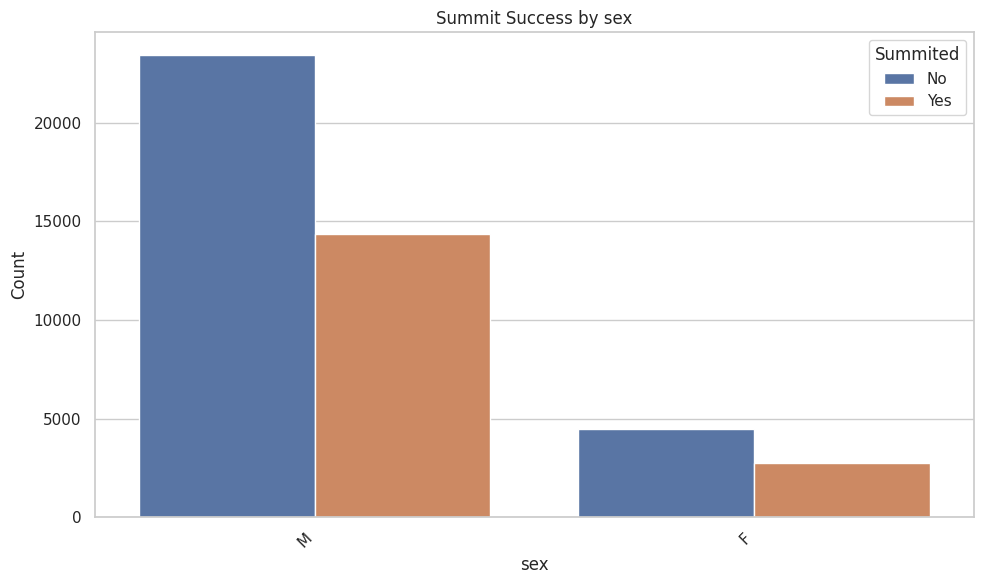

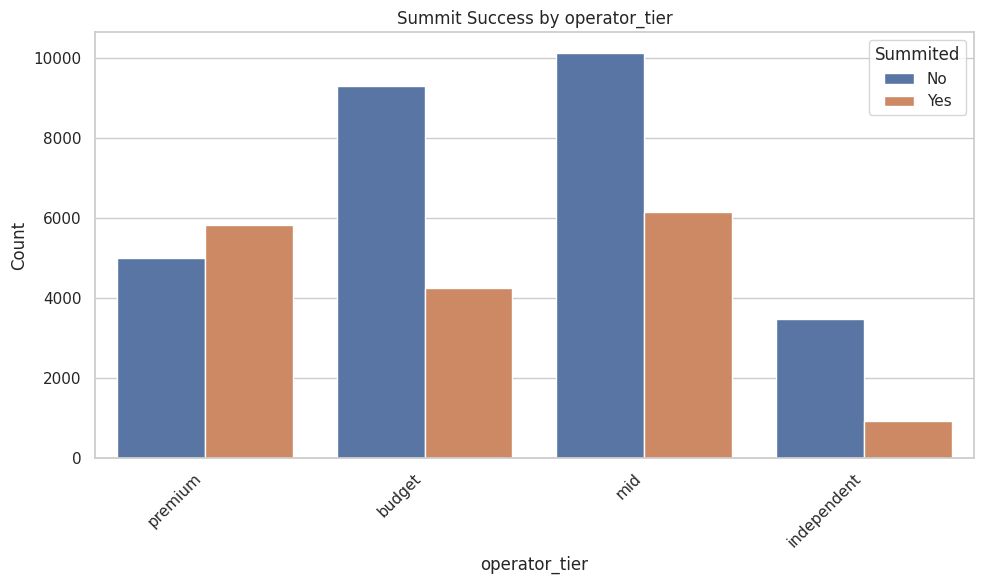

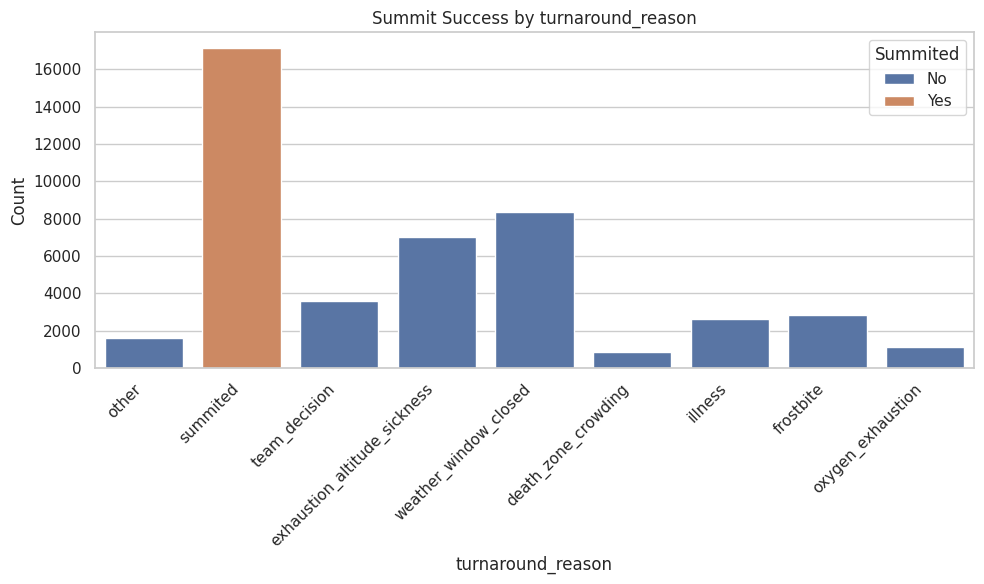

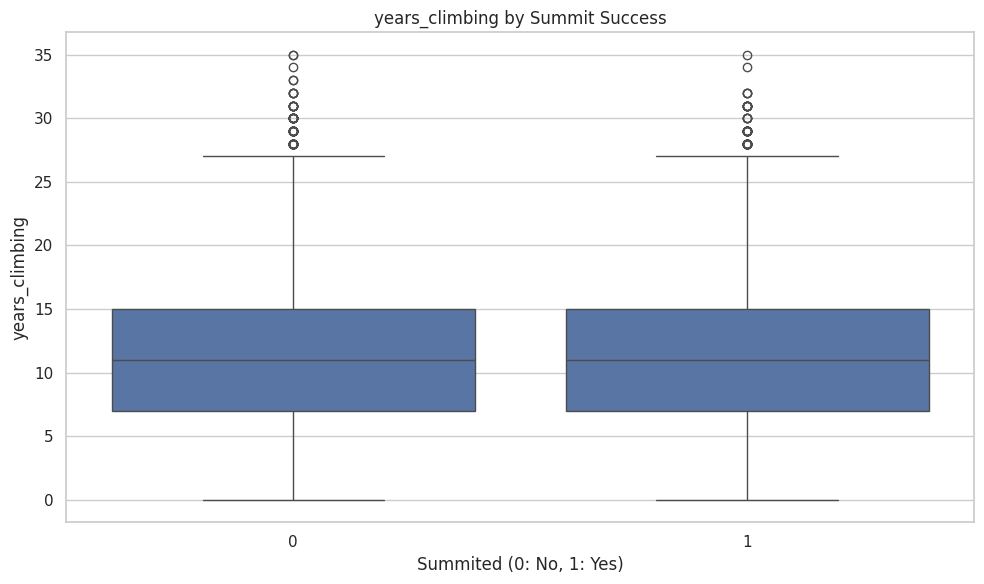

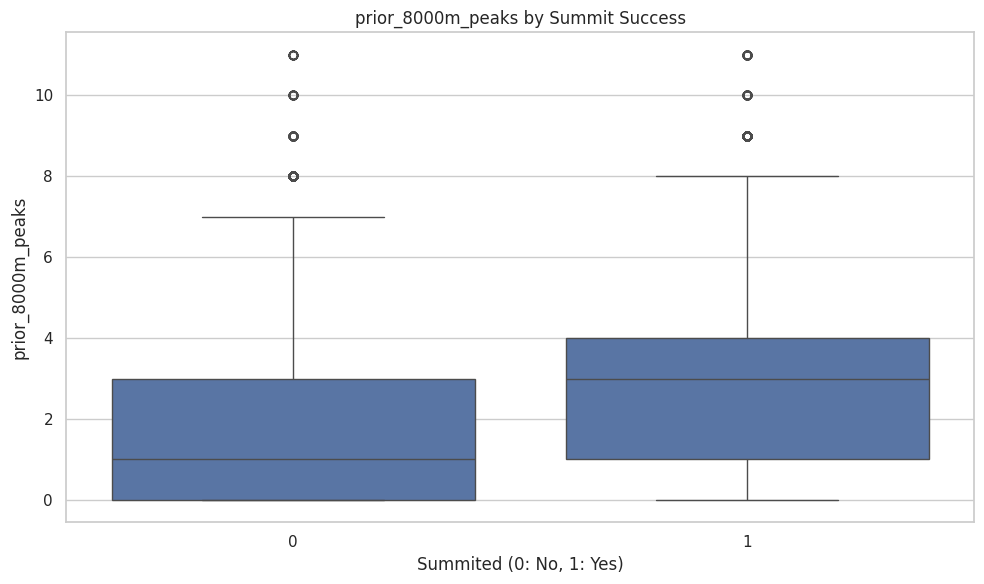

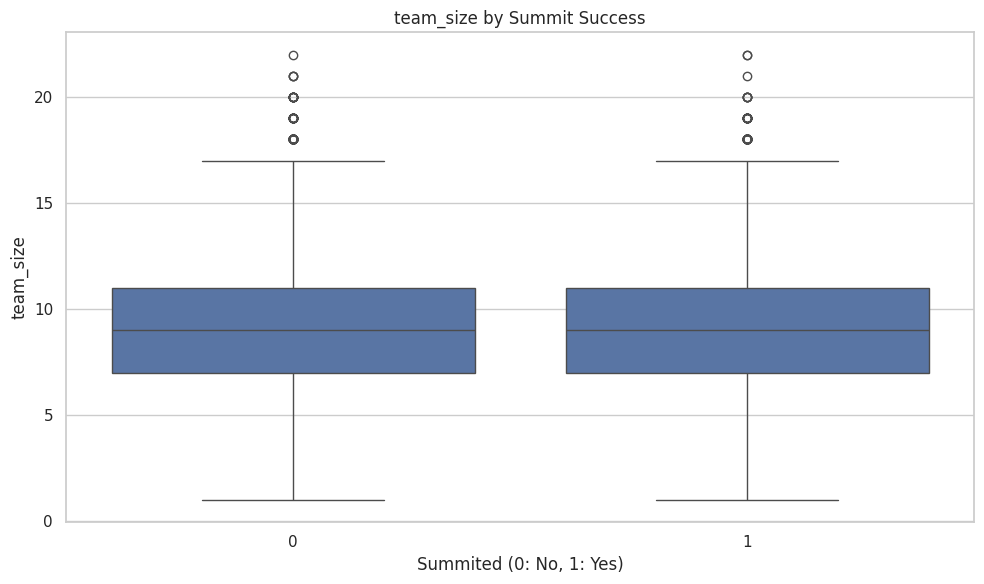

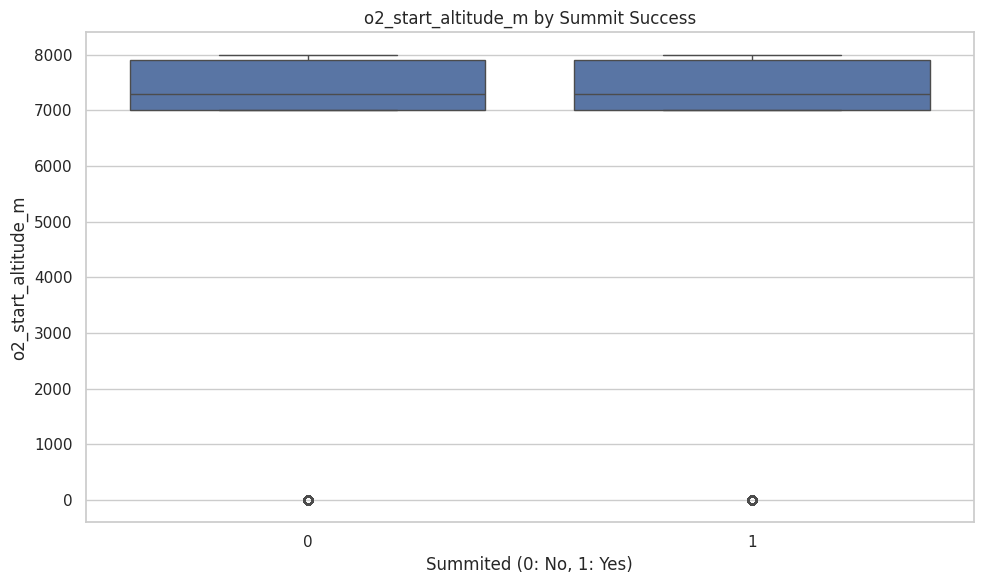

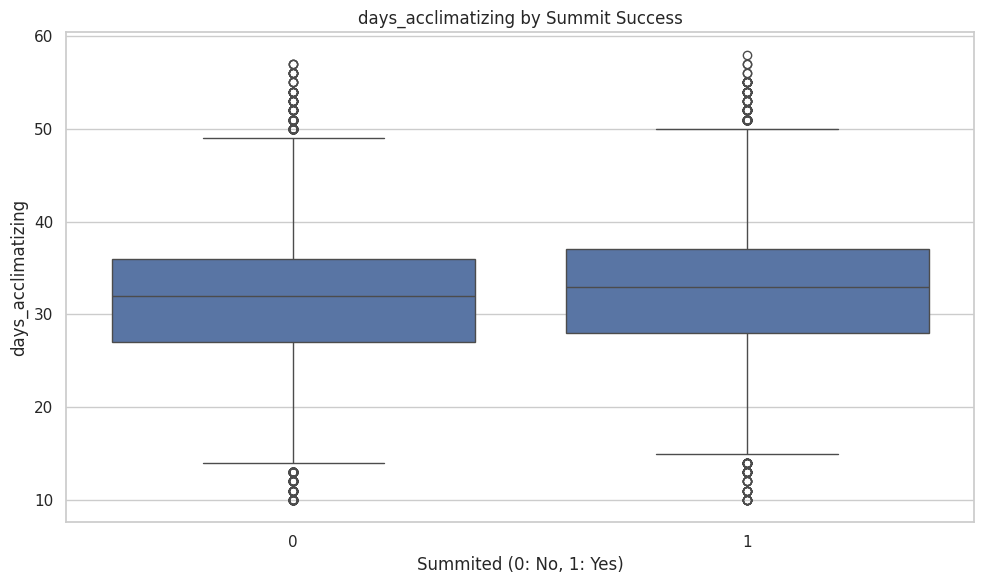

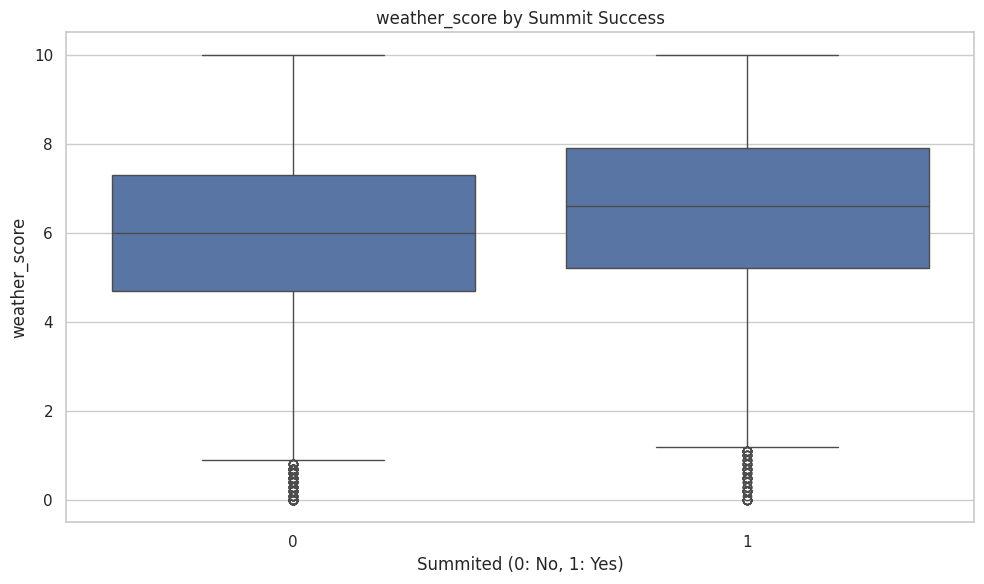

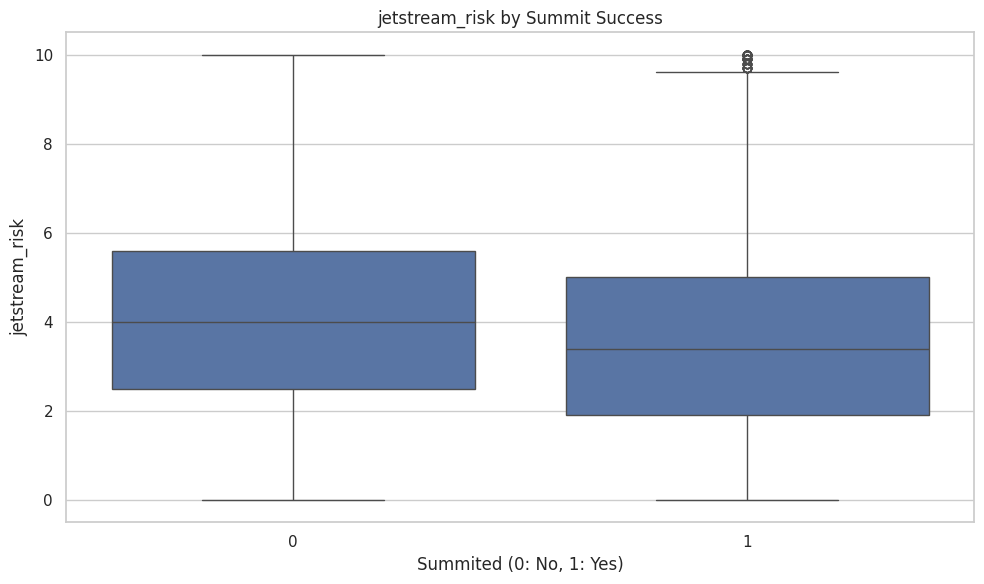

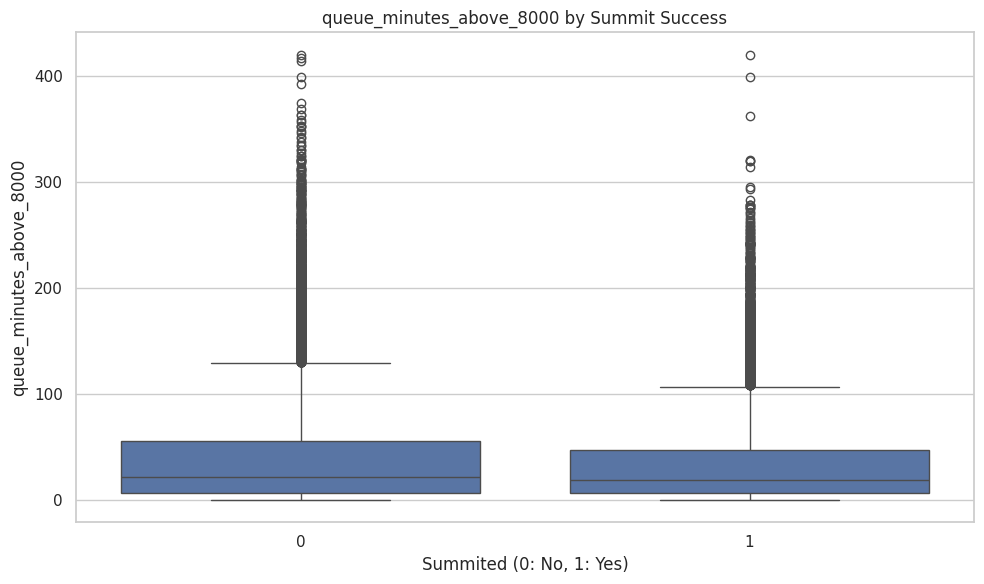

EDA complete. Check the generated plots for insights.


In [7]:
print("\n--- Further Exploratory Data Analysis ---\n")

# Analyze categorical variables vs. 'summited'
categorical_cols = ['season', 'route', 'sex', 'operator_tier', 'turnaround_reason']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='summited', data=df_clean)
    plt.title(f'Summit Success by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Summited', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

# Analyze numerical variables vs. 'summited' using box plots
numerical_cols_for_target = [
    'years_climbing', 'prior_8000m_peaks', 'team_size', 'o2_start_altitude_m',
    'days_acclimatizing', 'weather_score', 'jetstream_risk', 'queue_minutes_above_8000'
]

for col in numerical_cols_for_target:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='summited', y=col, data=df_clean)
    plt.title(f'{col} by Summit Success')
    plt.xlabel('Summited (0: No, 1: Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

print("EDA complete. Check the generated plots for insights.")

```markdown
## One-Hot Encoding of Categorical Variables

To prepare the data for modeling, we'll apply one-hot encoding to the categorical features. This converts categorical labels into a format that can be provided to ML algorithms to do a better prediction.
```

In [9]:
# Identify categorical columns (excluding 'climber_id' as it's an identifier)
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('climber_id') # Remove identifier column

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

# Re-define features to include the new one-hot encoded columns
# and exclude the original categorical columns and the target variable
features_encoded = [col for col in df_encoded.columns if col not in ['climber_id', 'summited']]

X_encoded = df_encoded[features_encoded]
y_encoded = df_encoded['summited']

# Split the encoded data into training and testing sets
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

print("Original number of features:", X.shape[1])
print("Number of features after one-hot encoding:", X_encoded.shape[1])
print("First 5 rows of encoded features (X_encoded):")
display(X_encoded.head())

# Update global variables for consistency with previous modeling steps
X = X_encoded
y = y_encoded
X_train = X_train_encoded
X_test = X_test_encoded
y_train = y_train_encoded
y_test = y_test_encoded
features = features_encoded

Original number of features: 14
Number of features after one-hot encoding: 35
First 5 rows of encoded features (X_encoded):


,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,...,operator_tier_mid,operator_tier_premium,turnaround_reason_exhaustion_altitude_sickness,turnaround_reason_frostbite,turnaround_reason_illness,turnaround_reason_other,turnaround_reason_oxygen_exhaustion,turnaround_reason_summited,turnaround_reason_team_decision,turnaround_reason_weather_window_closed
0,2025,56,0,15,0,1,5994,16,1.30,1,...,False,True,False,False,False,True,False,False,False,False
1,2020,47,0,7,0,1,6434,9,1.51,1,...,False,True,False,False,False,False,False,True,False,False
2,2022,24,1,19,1,0,8357,6,0.51,1,...,False,False,False,False,False,False,False,True,False,False
3,2024,50,0,12,3,0,8354,11,0.14,1,...,False,False,False,False,False,False,False,False,True,False
4,2015,60,0,1,1,0,8014,9,1.52,1,...,True,False,True,False,False,False,False,False,False,False


```markdown
## Investigating Potential Data Leakage

The exceptionally high model accuracies after one-hot encoding, particularly the Random Forest achieving 100%, strongly suggest data leakage. We need to examine the `turnaround_reason` column more closely, as it's a common source of such issues when directly related to the target variable.
```

In [12]:
print("Unique values in 'turnaround_reason' column:")
print(df_clean['turnaround_reason'].value_counts())

# Check if 'summited' is explicitly present or implied in turnaround_reason
if 'summited' in df_clean['turnaround_reason'].unique():
    print("\n--- CONFIRMED DATA LEAKAGE ---")
    print("The 'turnaround_reason' column contains 'summited' as a category, directly indicating the target variable. This is a clear case of data leakage.")
    print("We must drop this column to build a valid predictive model.")

    # Drop the problematic column and re-prepare the data
    df_no_leakage = df_clean.drop(columns=['turnaround_reason'])

    # Re-identify categorical columns (excluding 'climber_id' and the dropped 'turnaround_reason')
    categorical_cols_no_leakage = df_no_leakage.select_dtypes(include='object').columns.tolist()
    if 'climber_id' in categorical_cols_no_leakage:
        categorical_cols_no_leakage.remove('climber_id')

    # Re-apply one-hot encoding
    df_encoded_no_leakage = pd.get_dummies(df_no_leakage, columns=categorical_cols_no_leakage, drop_first=True)

    # Re-define features to include the new one-hot encoded columns
    features_no_leakage = [col for col in df_encoded_no_leakage.columns if col not in ['climber_id', 'summited']]

    X_no_leakage = df_encoded_no_leakage[features_no_leakage]
    y_no_leakage = df_encoded_no_leakage['summited']

    # Split the encoded data into training and testing sets
    X_train_no_leakage, X_test_no_leakage, y_train_no_leakage, y_test_no_leakage = train_test_split(
        X_no_leakage, y_no_leakage, test_size=0.2, random_state=42
    )

    print("\nNumber of features after removing 'turnaround_reason' and re-encoding:", X_no_leakage.shape[1])
    print("First 5 rows of new encoded features (X_no_leakage):")
    display(X_no_leakage.head())

    # Update global variables for consistency with subsequent modeling steps
    global X, y, X_train, X_test, y_train, y_test, features
    X = X_no_leakage
    y = y_no_leakage
    X_train = X_train_no_leakage
    X_test = X_test_no_leakage
    y_train = y_train_no_leakage
    y_test = y_test_no_leakage
    features = features_no_leakage

else:
    print("\n'turnaround_reason' does not explicitly contain 'summited'. Further investigation into other features may be needed if data leakage persists.")

Unique values in 'turnaround_reason' column:
turnaround_reason
summited                        17119
weather_window_closed            8338
exhaustion_altitude_sickness     6988
team_decision                    3585
frostbite                        2809
illness                          2612
other                            1600
oxygen_exhaustion                1099
death_zone_crowding               850
Name: count, dtype: int64

--- CONFIRMED DATA LEAKAGE ---
The 'turnaround_reason' column contains 'summited' as a category, directly indicating the target variable. This is a clear case of data leakage.
We must drop this column to build a valid predictive model.

Number of features after removing 'turnaround_reason' and re-encoding: 27
First 5 rows of new encoded features (X_no_leakage):


,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,...,serious_incident,season_spring,season_summer,season_winter,route_South Col-SE Ridge,route_other,sex_M,operator_tier_independent,operator_tier_mid,operator_tier_premium
0,2025,56,0,15,0,1,5994,16,1.30,1,...,0,True,False,False,True,False,True,False,False,True
1,2020,47,0,7,0,1,6434,9,1.51,1,...,0,True,False,False,False,False,True,False,False,True
2,2022,24,1,19,1,0,8357,6,0.51,1,...,0,False,False,False,True,False,True,False,False,False
3,2024,50,0,12,3,0,8354,11,0.14,1,...,0,True,False,False,True,False,False,False,False,False
4,2015,60,0,1,1,0,8014,9,1.52,1,...,0,True,False,False,False,False,False,False,True,False


## Conclusions and Future Work

This analysis provides a baseline understanding of the factors that might influence the success of Everest summit attempts. The logistic regression predictor, while simple, achieved a measurable accuracy and highlighted several important features through permutation importance.

Future work may include:

- Exploring additional feature engineering techniques
- Trying more sophisticated models (e.g., random forests, gradient boosting)
- Analyzing the temporal trends if date information becomes available
- Investigating the role of categorical variables via more in-depth encoding

These methods might improve predictive performance and provide a deeper insight into the dynamics of high-altitude climbing.

If you found this notebook useful, please consider upvoting it.